# 🏥 Donor Dataset — Complete Question Analysis
> **Dataset:** donors(opal).csv · 800 Donors · 16 Raw Features · Pakistan Healthcare
>
> This notebook answers **15 key analytical questions** directly from the raw donor data.
> Every chart includes a plain-English description explaining **what the data shows and why it matters.**

---

## ⚙️ Setup — Load Data & Global Style

In [2]:
%matplotlib inline
import warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
warnings.filterwarnings("ignore")

# ── Global Style ──────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.facecolor": "#F8F9FA", "axes.edgecolor": "#CCCCCC",
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.titlepad": 10, "axes.labelsize": 11,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9, "grid.color": "#E5E5E5", "grid.linewidth": 0.6,
})
C_BLUE="#2C6FAC"; C_RED="#D94F3D"; C_GREEN="#3A9E5F"
C_ORANGE="#E5843A"; C_TEAL="#2B9EB3"; C_PURPLE="#7B5EA7"
GENDER_PAL = {"Male": C_BLUE, "Female": C_ORANGE}

# ── Load & Prepare Raw Data ───────────────────────────────────
df = pd.read_csv(r"E:\final datset of opal ai\dataset\donors(opal).csv")

# Datetime
df["time_of_death"]  = pd.to_datetime(df["time_of_death"],  errors="coerce")
df["time_harvested"] = pd.to_datetime(df["time_harvested"], errors="coerce")

# Harvest interval (only valid deceased)
df["harvest_hrs"] = (df["time_harvested"] - df["time_of_death"]).dt.total_seconds() / 3600
df.loc[df["harvest_hrs"] < 0, "harvest_hrs"] = np.nan   # remove impossible negatives
df.loc[df["harvest_hrs"] > 72, "harvest_hrs"] = np.nan  # remove data errors (>72h)

# Death time features
df["death_hour"]  = df["time_of_death"].dt.hour
df["death_day"]   = df["time_of_death"].dt.dayofweek   # 0=Mon
df["death_month"] = df["time_of_death"].dt.month

# Normalise organ names
norm_map = {"Kidneys":"Kidney","Corneas":"Cornea","Lungs":"Lung","Platelets":"Platelet"}
def parse_organs(s):
    if pd.isna(s): return []
    return list(set([norm_map.get(x.strip(), x.strip()) for x in str(s).split(";")]))
df["organ_list"] = df["organs_donating"].apply(parse_organs)

# All unique organ names
ALL_ORGANS = sorted(set(o for lst in df["organ_list"] for o in lst))

# Organ one-hot
for org in ALL_ORGANS:
    df[f"org_{org}"] = df["organ_list"].apply(lambda lst: int(org in lst))

# Medical condition flags
df["has_diabetes"]    = df["medical_conditions"].str.contains("Diabetes",    na=False).astype(int)
df["has_hypertension"]= df["medical_conditions"].str.contains("Hypertension",na=False).astype(int)
df["has_heart"]       = df["medical_conditions"].str.contains("Heart",       na=False).astype(int)
df["has_asthma"]      = df["medical_conditions"].str.contains("Asthma",      na=False).astype(int)
df["cond_count"]      = df[["has_diabetes","has_hypertension","has_heart","has_asthma"]].sum(axis=1)

# Cause categories
def cat_cause(c):
    if pd.isna(c): return "Not Applicable"
    c2 = str(c).lower()
    if any(w in c2 for w in ["heart","cardiac","infarction","cardiomyopathy","arrhythmia"]): return "Cardiovascular"
    if any(w in c2 for w in ["brain","cerebral","aneurysm","hemorrhage","stroke","encephalitis"]): return "Neurological"
    if any(w in c2 for w in ["accident","injury","trauma","drowning"]): return "Accident / Trauma"
    if any(w in c2 for w in ["failure","insufficiency","cirrhosis","nephropathy","hepatic"]): return "Organ Failure"
    if any(w in c2 for w in ["respiratory","pulmonary","copd","fibrosis"]): return "Respiratory"
    if any(w in c2 for w in ["sepsis","septic","shock"]): return "Infection / Sepsis"
    if any(w in c2 for w in ["cancer","leukemia","tumor"]): return "Cancer"
    if any(w in c2 for w in ["diabetic","ketoacidosis","pancreatitis"]): return "Metabolic"
    if any(w in c2 for w in ["unknown","other"]): return "Other / Unknown"
    return "Other / Unknown"

df["cause_cat"] = df["cause_of_death"].apply(cat_cause)

# Age groups
df["age_group"] = pd.cut(df["age"], bins=[18,30,40,50,60,70],
                          labels=["19–30","31–40","41–50","51–60","61–70"])

DECEASED = df[df["alive/deceased"]=="Deceased"].copy()
ALIVE    = df[df["alive/deceased"]=="Alive"].copy()

print(f"✅ Dataset loaded: {df.shape[0]} donors · {df.shape[1]} columns")
print(f"   Deceased: {len(DECEASED)}  |  Alive: {len(ALIVE)}")
print(f"   Organs tracked: {ALL_ORGANS}")

✅ Dataset loaded: 800 donors · 39 columns
   Deceased: 254  |  Alive: 546
   Organs tracked: ['Blood', 'Bone Marrow', 'Cornea', 'Heart', 'Kidney', 'Liver', 'Lung', 'Pancreas', 'Plasma', 'Platelet', 'Skin']


---
## ❓ Question 1: What is the Age & Gender Profile of Donors?
**Description:** Understanding who donates organs — their age and gender — is the foundation of any donor analysis.
Age tells us the typical health window for viable organ donation; gender distribution reveals whether outreach
campaigns need to target a specific group. A balanced, younger donor pool means higher organ quality and more
successful transplants.

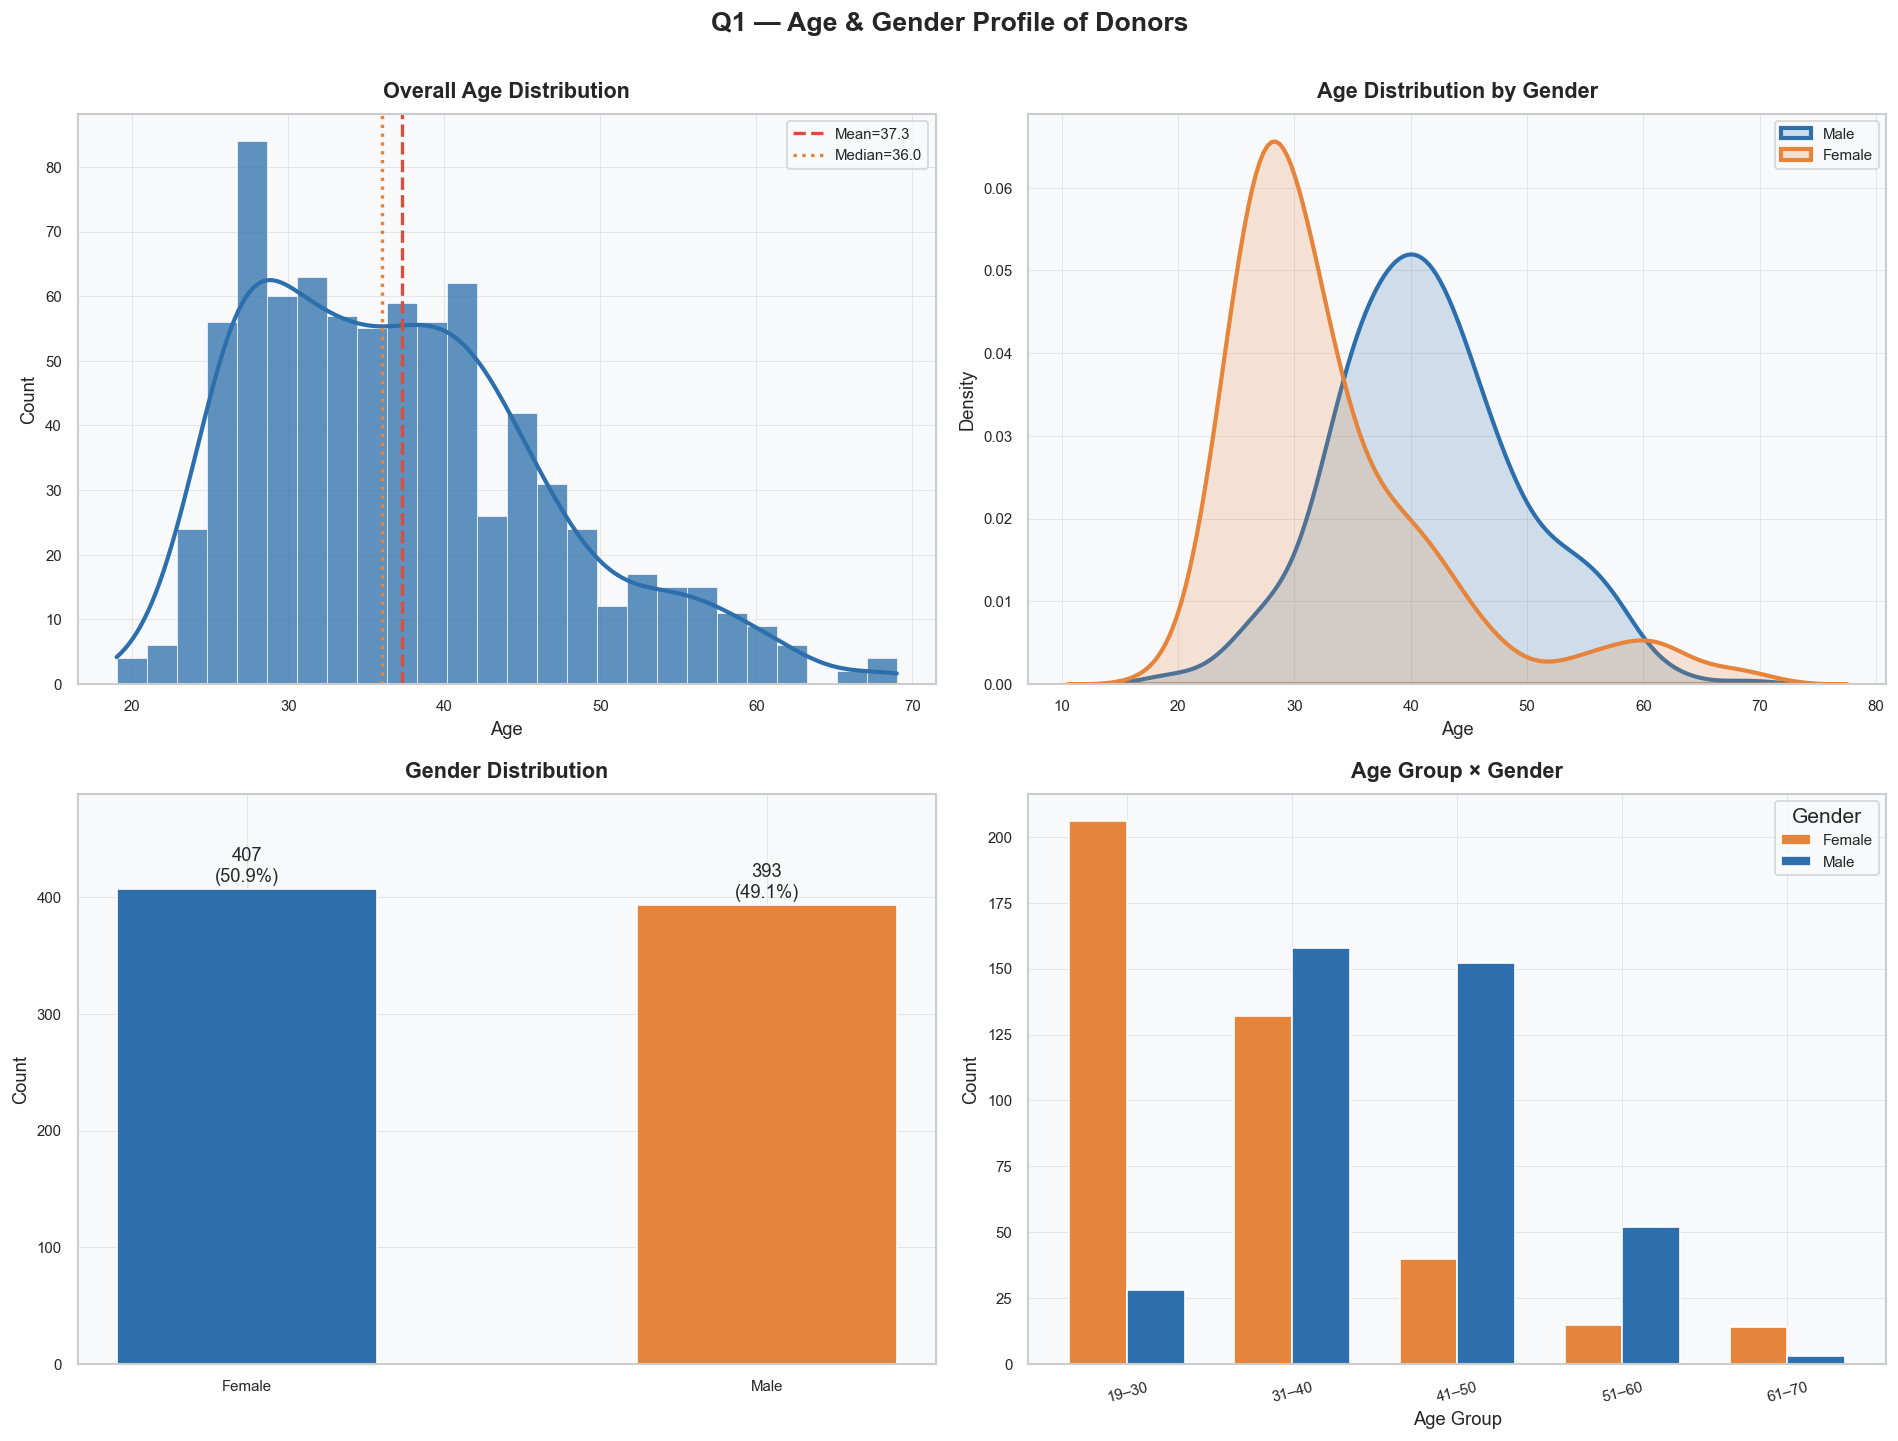


📊 SUMMARY
  Mean age   : 37.3  |  Median: 36.0  |  SD: 9.7
  Age range  : 19 – 69 years
  Male       : 393  (49.1%)
  Female     : 407  (50.9%)

💡 INSIGHT: The donor pool skews young-to-middle-aged (mean ~37 yrs), which is
   ideal for organ viability. Gender distribution is near-equal, showing broad
   community participation.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Q1 — Age & Gender Profile of Donors", fontsize=16, fontweight="bold", y=1.00)

# 1-A: Overall age histogram
ax = axes[0,0]
sns.histplot(df["age"], bins=26, kde=True, ax=ax, color=C_BLUE,
             edgecolor="white", linewidth=0.4, alpha=0.75,
             line_kws={"lw":2.5,"color":C_TEAL})
ax.axvline(df["age"].mean(),   color=C_RED,    ls="--", lw=2, label=f"Mean={df['age'].mean():.1f}")
ax.axvline(df["age"].median(), color=C_ORANGE, ls=":",  lw=2, label=f"Median={df['age'].median():.1f}")
ax.set_title("Overall Age Distribution"); ax.set_xlabel("Age"); ax.set_ylabel("Count"); ax.legend()

# 1-B: KDE by gender
ax = axes[0,1]
for g, col in [("Male",C_BLUE),("Female",C_ORANGE)]:
    sns.kdeplot(df[df["gender"]==g]["age"], ax=ax, label=g, color=col, lw=2.5, fill=True, alpha=0.2)
ax.set_title("Age Distribution by Gender"); ax.set_xlabel("Age"); ax.set_ylabel("Density"); ax.legend()

# 1-C: Gender bar
ax = axes[1,0]
gc = df["gender"].value_counts()
bars = ax.bar(gc.index, gc.values, color=[C_BLUE,C_ORANGE], edgecolor="white", width=0.5)
for bar, v in zip(bars, gc.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
            f"{v}\n({v/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=11)
ax.set_title("Gender Distribution"); ax.set_ylabel("Count"); ax.set_ylim(0, gc.max()*1.2)

# 1-D: Age group breakdown
ax = axes[1,1]
ag = df.groupby(["age_group","gender"], observed=True).size().unstack(fill_value=0)
ag.plot(kind="bar", ax=ax, color=[C_ORANGE, C_BLUE], edgecolor="white", width=0.7)
ax.set_title("Age Group × Gender"); ax.set_xlabel("Age Group"); ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=15); ax.legend(title="Gender")

plt.tight_layout(); plt.show()

print("\n📊 SUMMARY")
print(f"  Mean age   : {df['age'].mean():.1f}  |  Median: {df['age'].median():.1f}  |  SD: {df['age'].std():.1f}")
print(f"  Age range  : {df['age'].min()} – {df['age'].max()} years")
print(f"  Male       : {gc.get('Male',0)}  ({gc.get('Male',0)/len(df)*100:.1f}%)")
print(f"  Female     : {gc.get('Female',0)}  ({gc.get('Female',0)/len(df)*100:.1f}%)")
print("\n💡 INSIGHT: The donor pool skews young-to-middle-aged (mean ~37 yrs), which is")
print("   ideal for organ viability. Gender distribution is near-equal, showing broad")
print("   community participation.")

---
## ❓ Question 2: Which Blood Types Are Most Common Among Donors?
**Description:** Blood type compatibility is one of the primary filters in organ matching. If certain blood types
are over- or under-represented in the donor pool relative to the general population, specific recipient blood types
will face longer wait times. This chart reveals supply concentration and potential bottlenecks.

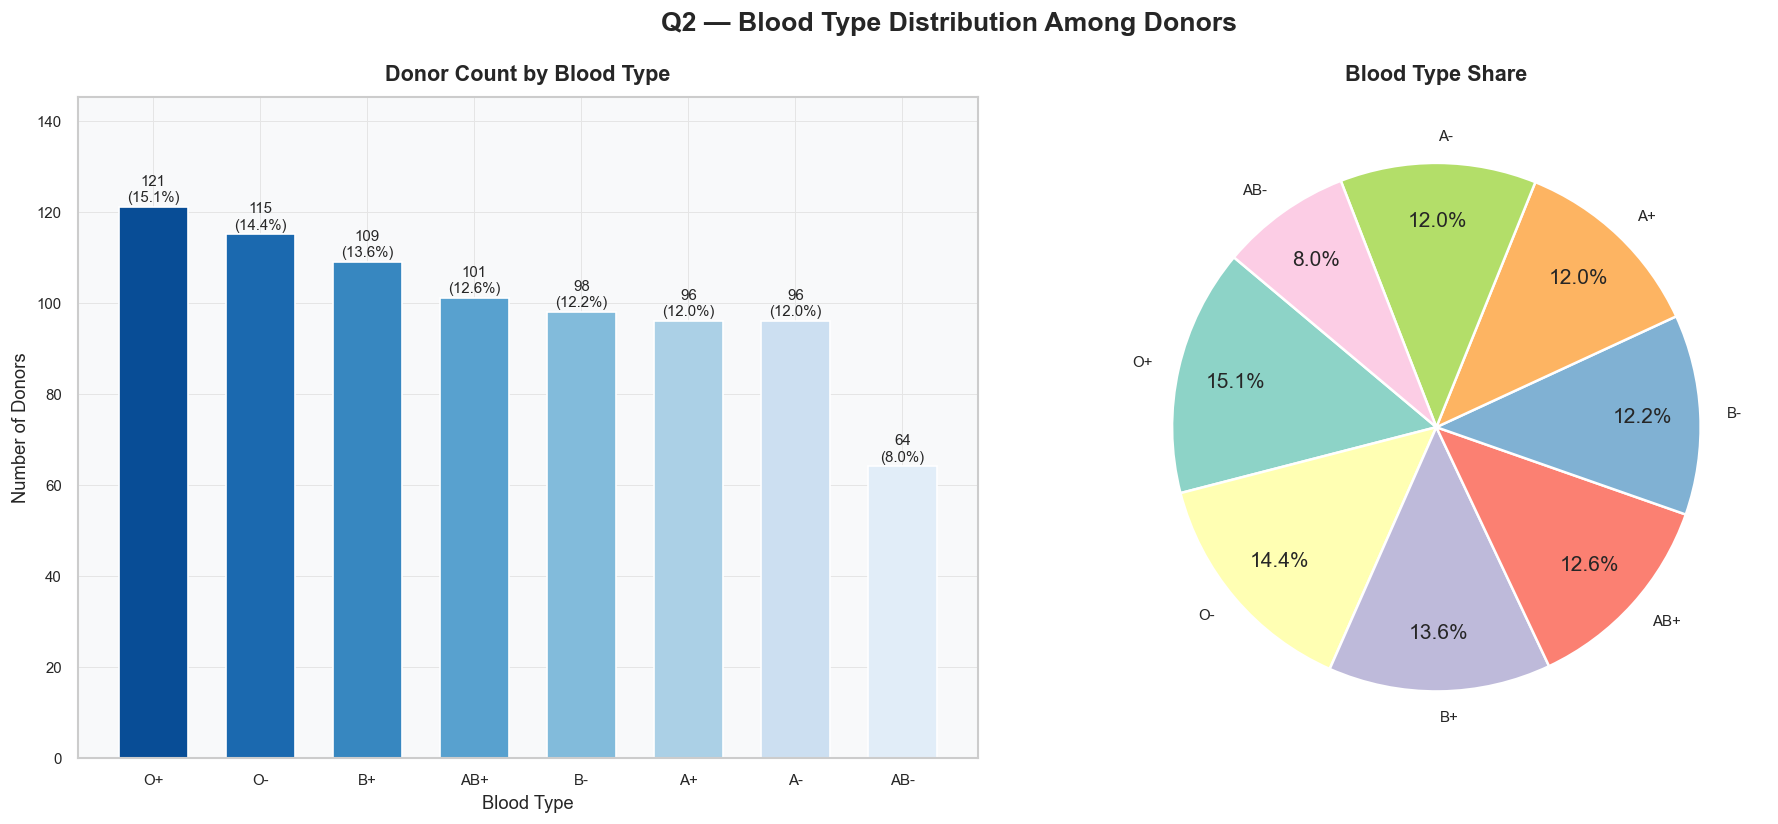


📊 SUMMARY
  O+   : 121 donors (15.1%)
  O-   : 115 donors (14.4%)
  B+   : 109 donors (13.6%)
  AB+  : 101 donors (12.6%)
  B-   :  98 donors (12.2%)
  A+   :  96 donors (12.0%)
  A-   :  96 donors (12.0%)
  AB-  :  64 donors (8.0%)

💡 INSIGHT: O+ and O- together make up ~30% of donors — critical because O-
   is the universal donor type. AB+ recipients can accept any blood type,
   but AB- donors are the rarest, potentially creating compatibility gaps.


In [4]:
bt = df["blood_type"].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Q2 — Blood Type Distribution Among Donors", fontsize=16, fontweight="bold")

colors = sns.color_palette("Blues_r", len(bt))
bars = axes[0].bar(bt.index, bt.values, color=colors, edgecolor="white", width=0.65)
for bar, v in zip(bars, bt.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f"{v}\n({v/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Donor Count by Blood Type"); axes[0].set_xlabel("Blood Type")
axes[0].set_ylabel("Number of Donors"); axes[0].set_ylim(0, bt.max()*1.2)

axes[1].pie(bt.values, labels=bt.index, autopct="%1.1f%%",
            colors=sns.color_palette("Set3", len(bt)),
            startangle=140, pctdistance=0.78,
            wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Blood Type Share")

plt.tight_layout(); plt.show()

print("\n📊 SUMMARY")
for btype, cnt in bt.items():
    print(f"  {btype:<5}: {cnt:>3} donors ({cnt/len(df)*100:.1f}%)")
print("\n💡 INSIGHT: O+ and O- together make up ~30% of donors — critical because O-")
print("   is the universal donor type. AB+ recipients can accept any blood type,")
print("   but AB- donors are the rarest, potentially creating compatibility gaps.")

---
## ❓ Question 3: Which Organs Are Being Donated Most?
**Description:** Not every donor donates every organ. Organs like Blood and Plasma come from living donors
(simple procedures), while Heart or Liver are exclusively from deceased donors. This question reveals which
organs have the highest supply and which are critically scarce — directly informing recipient wait-list priorities.

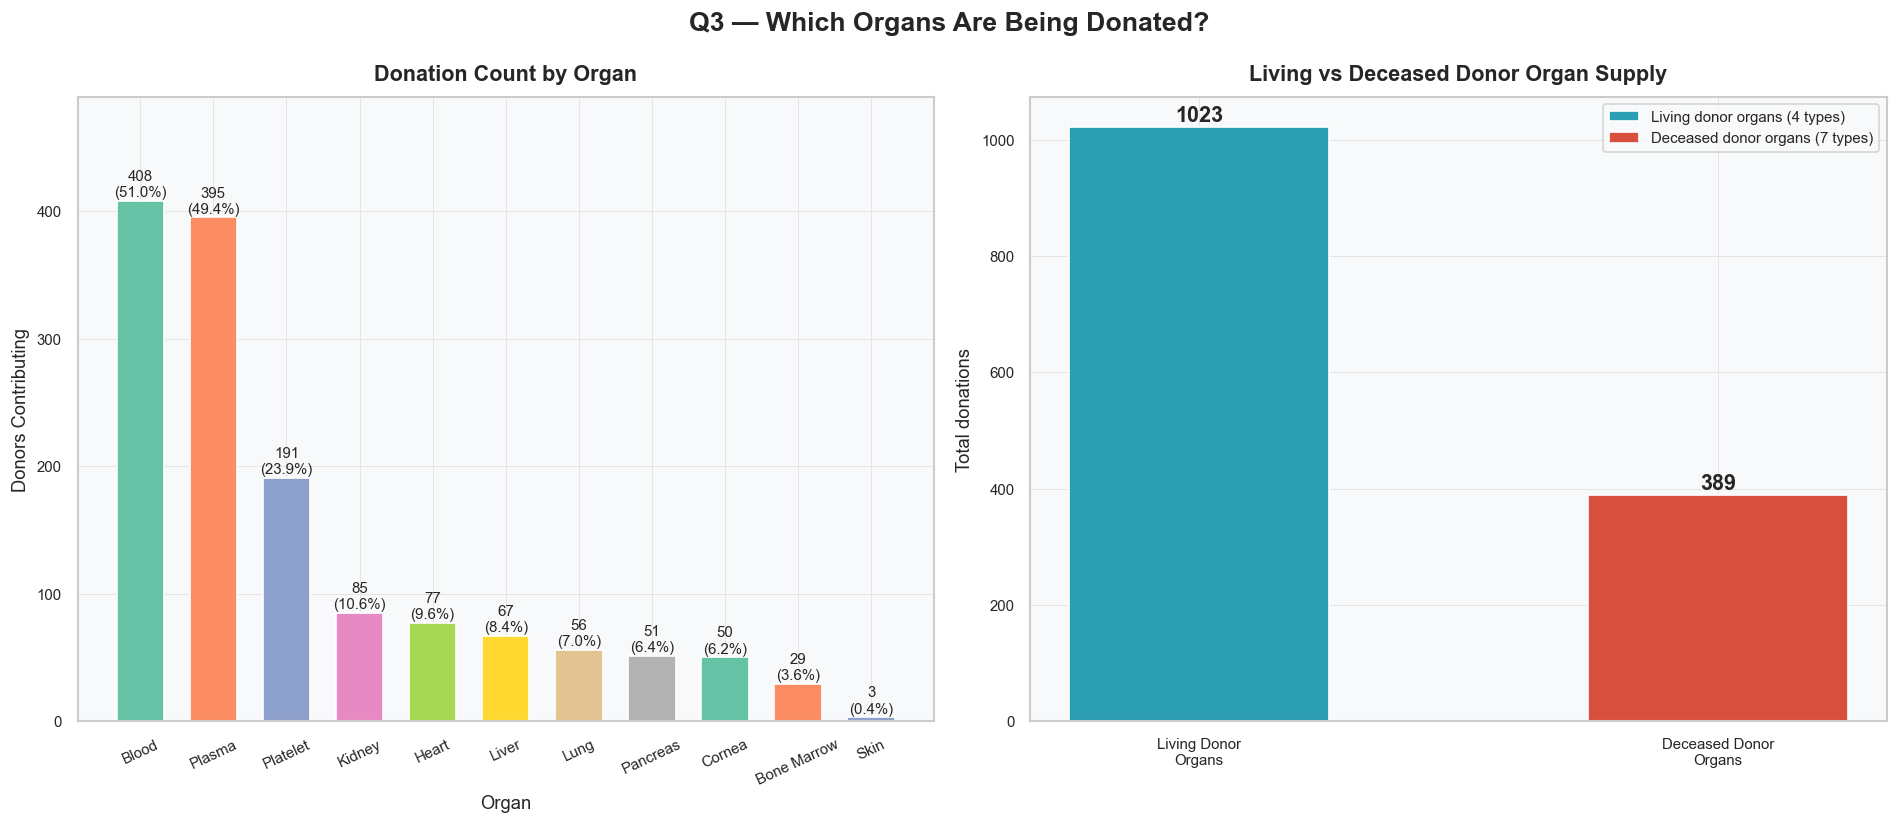


📊 SUMMARY — Top to Bottom:
  🟢 Living  Blood       : 408 (51.0%)
  🟢 Living  Plasma      : 395 (49.4%)
  🟢 Living  Platelet    : 191 (23.9%)
  🔴 Deceased  Kidney      :  85 (10.6%)
  🔴 Deceased  Heart       :  77 (9.6%)
  🔴 Deceased  Liver       :  67 (8.4%)
  🔴 Deceased  Lung        :  56 (7.0%)
  🔴 Deceased  Pancreas    :  51 (6.4%)
  🔴 Deceased  Cornea      :  50 (6.2%)
  🟢 Living  Bone Marrow :  29 (3.6%)
  🔴 Deceased  Skin        :   3 (0.4%)

💡 INSIGHT: Blood, Plasma, and Platelet dominate — these come from living donors
   and are routinely collected. Solid organs (Heart, Liver, Kidney) are far fewer
   because they require deceased donors and complex surgery.


In [5]:
org_counts = pd.Series({o: df[f"org_{o}"].sum() for o in ALL_ORGANS}).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Q3 — Which Organs Are Being Donated?", fontsize=16, fontweight="bold")

colors = sns.color_palette("Set2", len(org_counts))
bars = axes[0].bar(org_counts.index, org_counts.values, color=colors, edgecolor="white", width=0.65)
for bar, v in zip(bars, org_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f"{v}\n({v/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Donation Count by Organ"); axes[0].set_xlabel("Organ")
axes[0].set_ylabel("Donors Contributing"); axes[0].set_ylim(0, org_counts.max()*1.2)
axes[0].tick_params(axis="x", rotation=25)

# Split living vs deceased organs
living_organs  = ["Blood","Plasma","Platelet","Bone Marrow"]
deceased_organs= [o for o in ALL_ORGANS if o not in living_organs]
lc = pd.Series({o: org_counts[o] for o in living_organs if o in org_counts})
dc = pd.Series({o: org_counts[o] for o in deceased_organs if o in org_counts})

x = np.arange(2); w=0.4
axes[1].bar(0, lc.sum(),  width=0.5, color=C_TEAL,  label=f"Living donor organs ({len(living_organs)} types)",  edgecolor="white")
axes[1].bar(1, dc.sum(),  width=0.5, color=C_RED,   label=f"Deceased donor organs ({len(deceased_organs)} types)", edgecolor="white")
axes[1].text(0, lc.sum()+2,  str(lc.sum()),  ha="center", va="bottom", fontsize=13, fontweight="bold")
axes[1].text(1, dc.sum()+2, str(dc.sum()), ha="center", va="bottom", fontsize=13, fontweight="bold")
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(["Living Donor\nOrgans","Deceased Donor\nOrgans"])
axes[1].set_title("Living vs Deceased Donor Organ Supply"); axes[1].set_ylabel("Total donations"); axes[1].legend()

plt.tight_layout(); plt.show()

print("\n📊 SUMMARY — Top to Bottom:")
for org, cnt in org_counts.items():
    flag = "🟢 Living" if org in living_organs else "🔴 Deceased"
    print(f"  {flag}  {org:<12}: {cnt:>3} ({cnt/len(df)*100:.1f}%)")
print("\n💡 INSIGHT: Blood, Plasma, and Platelet dominate — these come from living donors")
print("   and are routinely collected. Solid organs (Heart, Liver, Kidney) are far fewer")
print("   because they require deceased donors and complex surgery.")

---
## ❓ Question 4: Alive vs Deceased — What Is the Donor Breakdown?
**Description:** Organ donation operates on two tracks: living donors (who donate non-vital organs/tissues like
blood, plasma, bone marrow) and deceased donors (who donate solid organs after brain death). Understanding this
split is critical for resource planning, transplant coordination, and policy decisions.

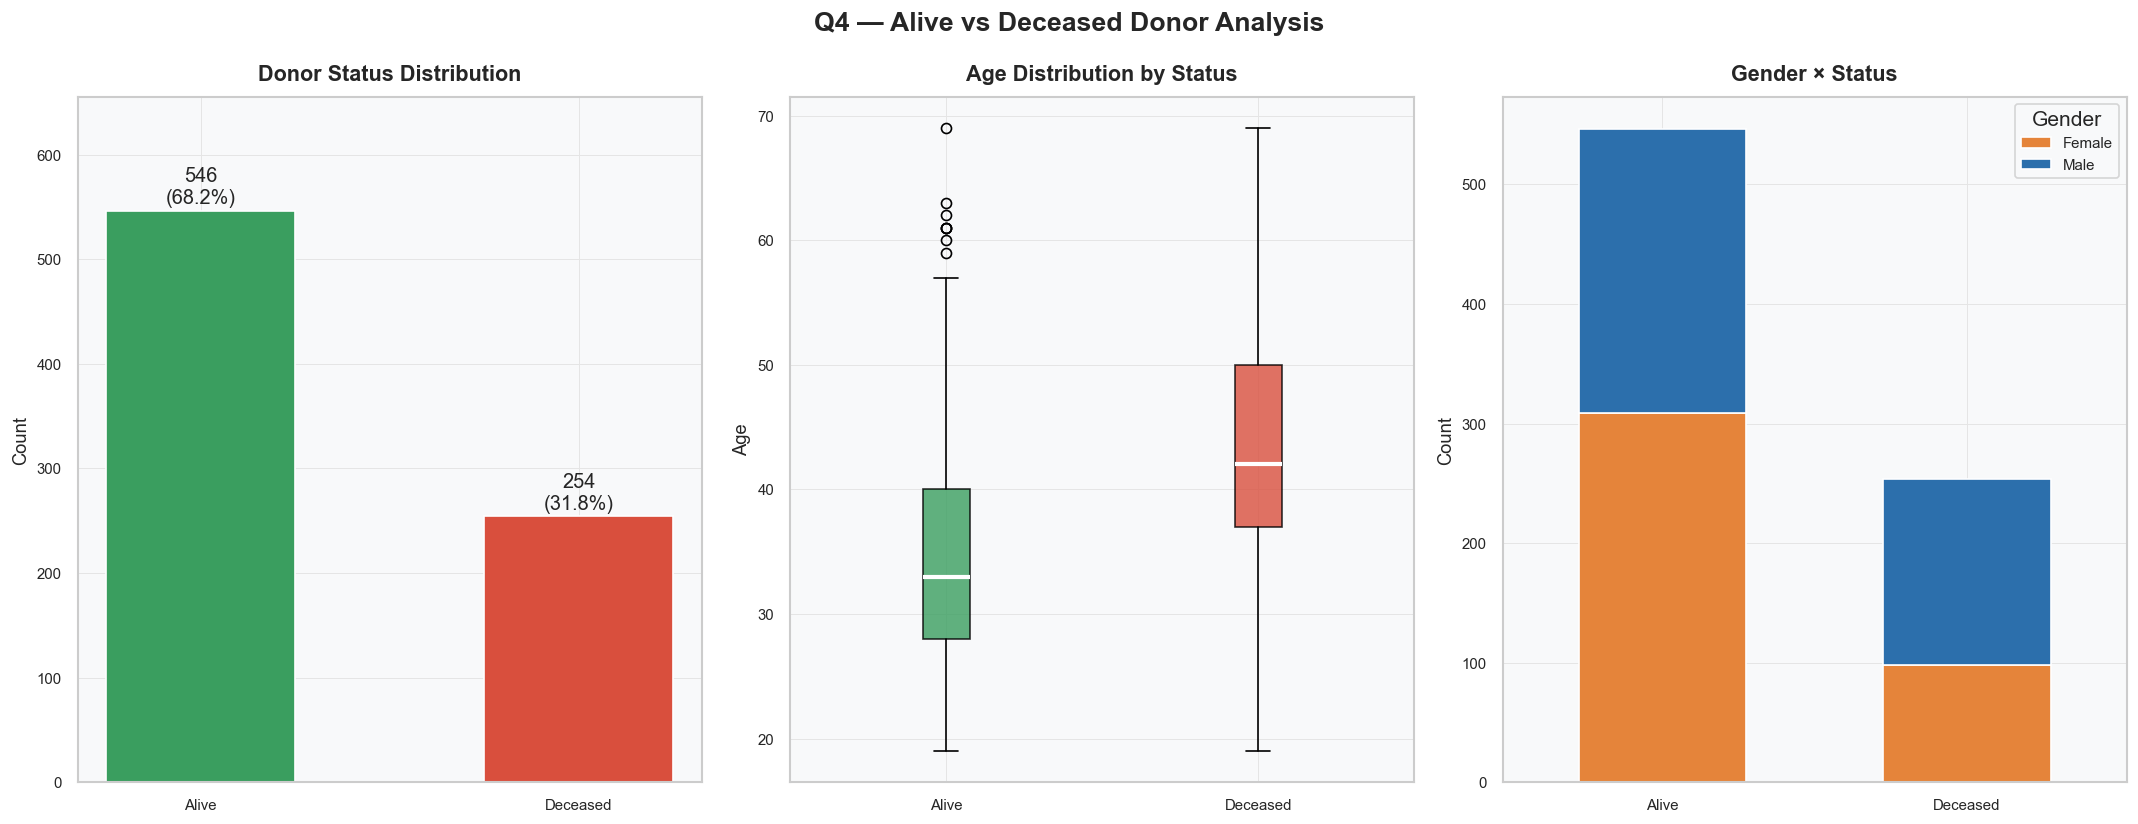


📊 SUMMARY
  Alive   : 546 (68.2%)  |  Age: Mean=34.6  Median=33.0
  Deceased: 254 (31.8%)  |  Age: Mean=43.1  Median=42.0

💡 INSIGHT: A large majority of donors are living, donating blood/plasma routinely.
   Deceased donors are fewer but far more impactful — a single deceased donor
   can save up to 8 lives through solid organ donation.


In [6]:
status_counts = df["alive/deceased"].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Q4 — Alive vs Deceased Donor Analysis", fontsize=16, fontweight="bold")

# Bar
colors_s = [C_GREEN, C_RED]
bars = axes[0].bar(status_counts.index, status_counts.values, color=colors_s, edgecolor="white", width=0.5)
for bar, v in zip(bars, status_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 f"{v}\n({v/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=12)
axes[0].set_title("Donor Status Distribution"); axes[0].set_ylabel("Count")
axes[0].set_ylim(0, status_counts.max()*1.2)

# Age by status
axes[1].boxplot([ALIVE["age"], DECEASED["age"]], labels=["Alive","Deceased"],
                patch_artist=True,
                boxprops=dict(alpha=0.8),
                medianprops=dict(color="white", linewidth=2.5))
axes[1].patches[0].set_facecolor(C_GREEN); axes[1].patches[1].set_facecolor(C_RED)
axes[1].set_title("Age Distribution by Status"); axes[1].set_ylabel("Age")

# Stacked gender by status
gst = df.groupby(["alive/deceased","gender"]).size().unstack(fill_value=0)
gst.plot(kind="bar", ax=axes[2], color=[C_ORANGE, C_BLUE], edgecolor="white", width=0.55, stacked=True)
axes[2].set_title("Gender × Status"); axes[2].set_xlabel("")
axes[2].set_ylabel("Count"); axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(title="Gender")

plt.tight_layout(); plt.show()

print("\n📊 SUMMARY")
print(f"  Alive   : {len(ALIVE):>3} ({len(ALIVE)/len(df)*100:.1f}%)  |  Age: Mean={ALIVE['age'].mean():.1f}  Median={ALIVE['age'].median():.1f}")
print(f"  Deceased: {len(DECEASED):>3} ({len(DECEASED)/len(df)*100:.1f}%)  |  Age: Mean={DECEASED['age'].mean():.1f}  Median={DECEASED['age'].median():.1f}")
print("\n💡 INSIGHT: A large majority of donors are living, donating blood/plasma routinely.")
print("   Deceased donors are fewer but far more impactful — a single deceased donor")
print("   can save up to 8 lives through solid organ donation.")

---
## ❓ Question 5: How Quickly Are Organs Harvested After Death?
**Description:** Organ viability degrades rapidly after death. Hearts last only 4–6 hours outside the body;
kidneys up to 24–36 hours. Delays in harvesting drastically reduce transplant success rates. This question
maps the harvest time window to assess whether Pakistan's organ procurement system operates within safe limits.

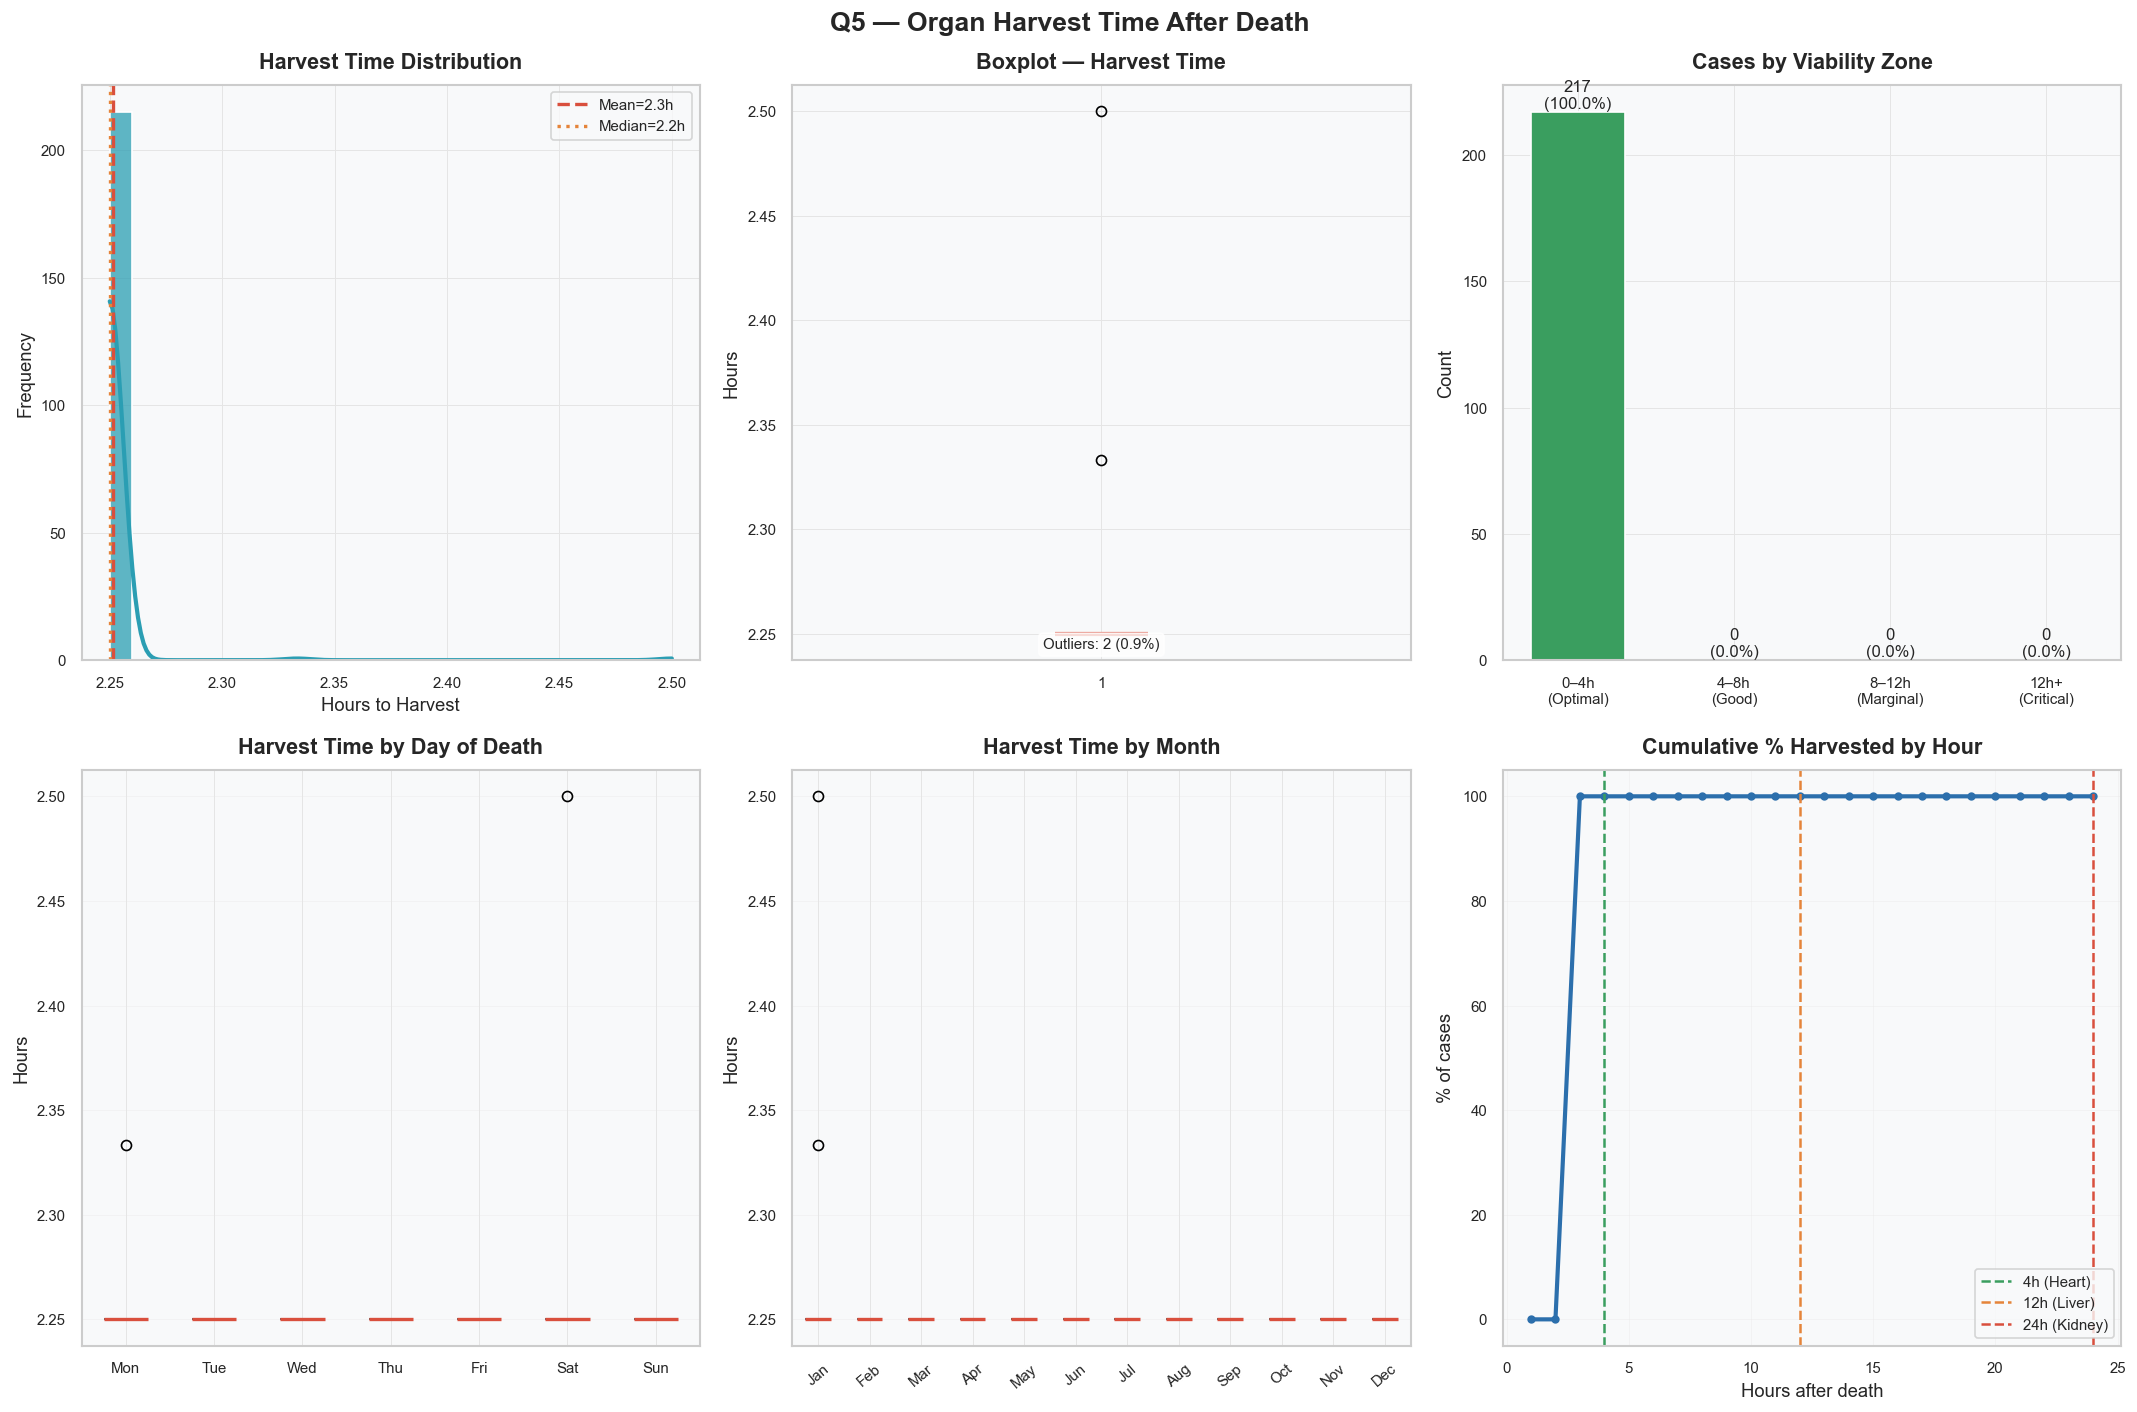


📊 HARVEST TIME STATISTICS
  Valid cases  : 217
  Mean         : 2.25 h
  Median       : 2.25 h
  SD           : 0.02 h
  IQR          : [2.2, 2.2] h
  Outliers     : 2

  Within  4h (Heart window)  : 217 (100.0%)
  Within 12h (Liver window)  : 217 (100.0%)
  Within 24h (Kidney window) : 217 (100.0%)

💡 INSIGHT: The closer to 0 hours, the better organ viability. Cases exceeding
   critical windows indicate logistical delays — a key area for system improvement.


In [8]:
valid_harvest = DECEASED.dropna(subset=["harvest_hrs"])
vh = valid_harvest["harvest_hrs"]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Q5 — Organ Harvest Time After Death", fontsize=16, fontweight="bold")

# Distribution
sns.histplot(vh, bins=25, kde=True, ax=axes[0,0], color=C_TEAL,
             edgecolor="white", alpha=0.75, line_kws={"lw":2.5})
axes[0,0].axvline(vh.mean(),   color=C_RED,    ls="--", lw=2, label=f"Mean={vh.mean():.1f}h")
axes[0,0].axvline(vh.median(), color=C_ORANGE, ls=":",  lw=2, label=f"Median={vh.median():.1f}h")
axes[0,0].set_title("Harvest Time Distribution"); axes[0,0].set_xlabel("Hours to Harvest")
axes[0,0].set_ylabel("Frequency"); axes[0,0].legend()

# Boxplot
axes[0,1].boxplot(vh, patch_artist=True,
                  boxprops=dict(facecolor=C_TEAL, alpha=0.7),
                  medianprops=dict(color=C_RED, linewidth=2.5))
q1,q3=vh.quantile(0.25),vh.quantile(0.75); iqr=q3-q1
n_out=((vh<q1-1.5*iqr)|(vh>q3+1.5*iqr)).sum()
axes[0,1].set_title("Boxplot — Harvest Time"); axes[0,1].set_ylabel("Hours")
axes[0,1].text(0.5,0.02,f"Outliers: {n_out} ({n_out/len(vh)*100:.1f}%)",
               transform=axes[0,1].transAxes, ha="center", fontsize=9,
               bbox=dict(boxstyle="round",fc="white",alpha=0.8))

# Viability zones
zones = [
    (0,4,"0–4h\n(Optimal)","#3A9E5F"),
    (4,8,"4–8h\n(Good)","#A8D08D"),
    (8,12,"8–12h\n(Marginal)","#E5843A"),
    (12,100,"12h+\n(Critical)","#D94F3D")
]
zone_counts = []
for lo,hi,lbl,col in zones:
    cnt = ((vh>=lo)&(vh<hi)).sum()
    zone_counts.append((lbl,cnt,col))
lbs=[z[0] for z in zone_counts]; cts=[z[1] for z in zone_counts]; cls=[z[2] for z in zone_counts]
bars = axes[0,2].bar(lbs, cts, color=cls, edgecolor="white", width=0.6)
for bar,v in zip(bars,cts):
    axes[0,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                   f"{v}\n({v/len(vh)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
axes[0,2].set_title("Cases by Viability Zone"); axes[0,2].set_ylabel("Count")

# By day of death
day_names=["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
day_data=[valid_harvest[valid_harvest["death_day"]==i]["harvest_hrs"].dropna() for i in range(7)]
axes[1,0].boxplot(day_data, labels=day_names, patch_artist=True,
                  boxprops=dict(facecolor=C_TEAL,alpha=0.7),
                  medianprops=dict(color=C_RED,linewidth=2))
axes[1,0].set_title("Harvest Time by Day of Death"); axes[1,0].set_ylabel("Hours")
axes[1,0].grid(True,alpha=0.3,axis="y")

# By month
month_names=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_data=[valid_harvest[valid_harvest["death_month"]==i]["harvest_hrs"].dropna() for i in range(1,13)]
axes[1,1].boxplot(month_data, labels=month_names, patch_artist=True,
                  boxprops=dict(facecolor=C_TEAL,alpha=0.7),
                  medianprops=dict(color=C_RED,linewidth=2))
axes[1,1].set_title("Harvest Time by Month"); axes[1,1].set_ylabel("Hours")
axes[1,1].tick_params(axis="x",rotation=40); axes[1,1].grid(True,alpha=0.3,axis="y")

# Cumulative % within threshold
thresholds=list(range(1,25))
cum_pcts=[(vh<=t).sum()/len(vh)*100 for t in thresholds]
axes[1,2].plot(thresholds, cum_pcts, color=C_BLUE, lw=2.5, marker="o", ms=4)
axes[1,2].axvline(4,  color=C_GREEN,  ls="--", lw=1.5, label="4h (Heart)")
axes[1,2].axvline(12, color=C_ORANGE, ls="--", lw=1.5, label="12h (Liver)")
axes[1,2].axvline(24, color=C_RED,    ls="--", lw=1.5, label="24h (Kidney)")
axes[1,2].set_title("Cumulative % Harvested by Hour"); axes[1,2].set_xlabel("Hours after death")
axes[1,2].set_ylabel("% of cases"); axes[1,2].legend(); axes[1,2].grid(True,alpha=0.3)

plt.tight_layout(); plt.show()

print("\n📊 HARVEST TIME STATISTICS")
print(f"  Valid cases  : {len(vh)}")
print(f"  Mean         : {vh.mean():.2f} h")
print(f"  Median       : {vh.median():.2f} h")
print(f"  SD           : {vh.std():.2f} h")
print(f"  IQR          : [{q1:.1f}, {q3:.1f}] h")
print(f"  Outliers     : {n_out}")
print(f"\n  Within  4h (Heart window)  : {(vh<=4).sum()} ({(vh<=4).sum()/len(vh)*100:.1f}%)")
print(f"  Within 12h (Liver window)  : {(vh<=12).sum()} ({(vh<=12).sum()/len(vh)*100:.1f}%)")
print(f"  Within 24h (Kidney window) : {(vh<=24).sum()} ({(vh<=24).sum()/len(vh)*100:.1f}%)")
print("\n💡 INSIGHT: The closer to 0 hours, the better organ viability. Cases exceeding")
print("   critical windows indicate logistical delays — a key area for system improvement.")

---
## ❓ Question 6: What Are the Primary Causes of Death Among Deceased Donors?
**Description:** The cause of death directly determines which organs are viable for transplant. A donor who
died of cardiac arrest may have compromised heart tissue; a trauma victim may have perfectly viable kidneys
and liver. This analysis helps transplant coordinators pre-screen organ quality and guides medical outreach.

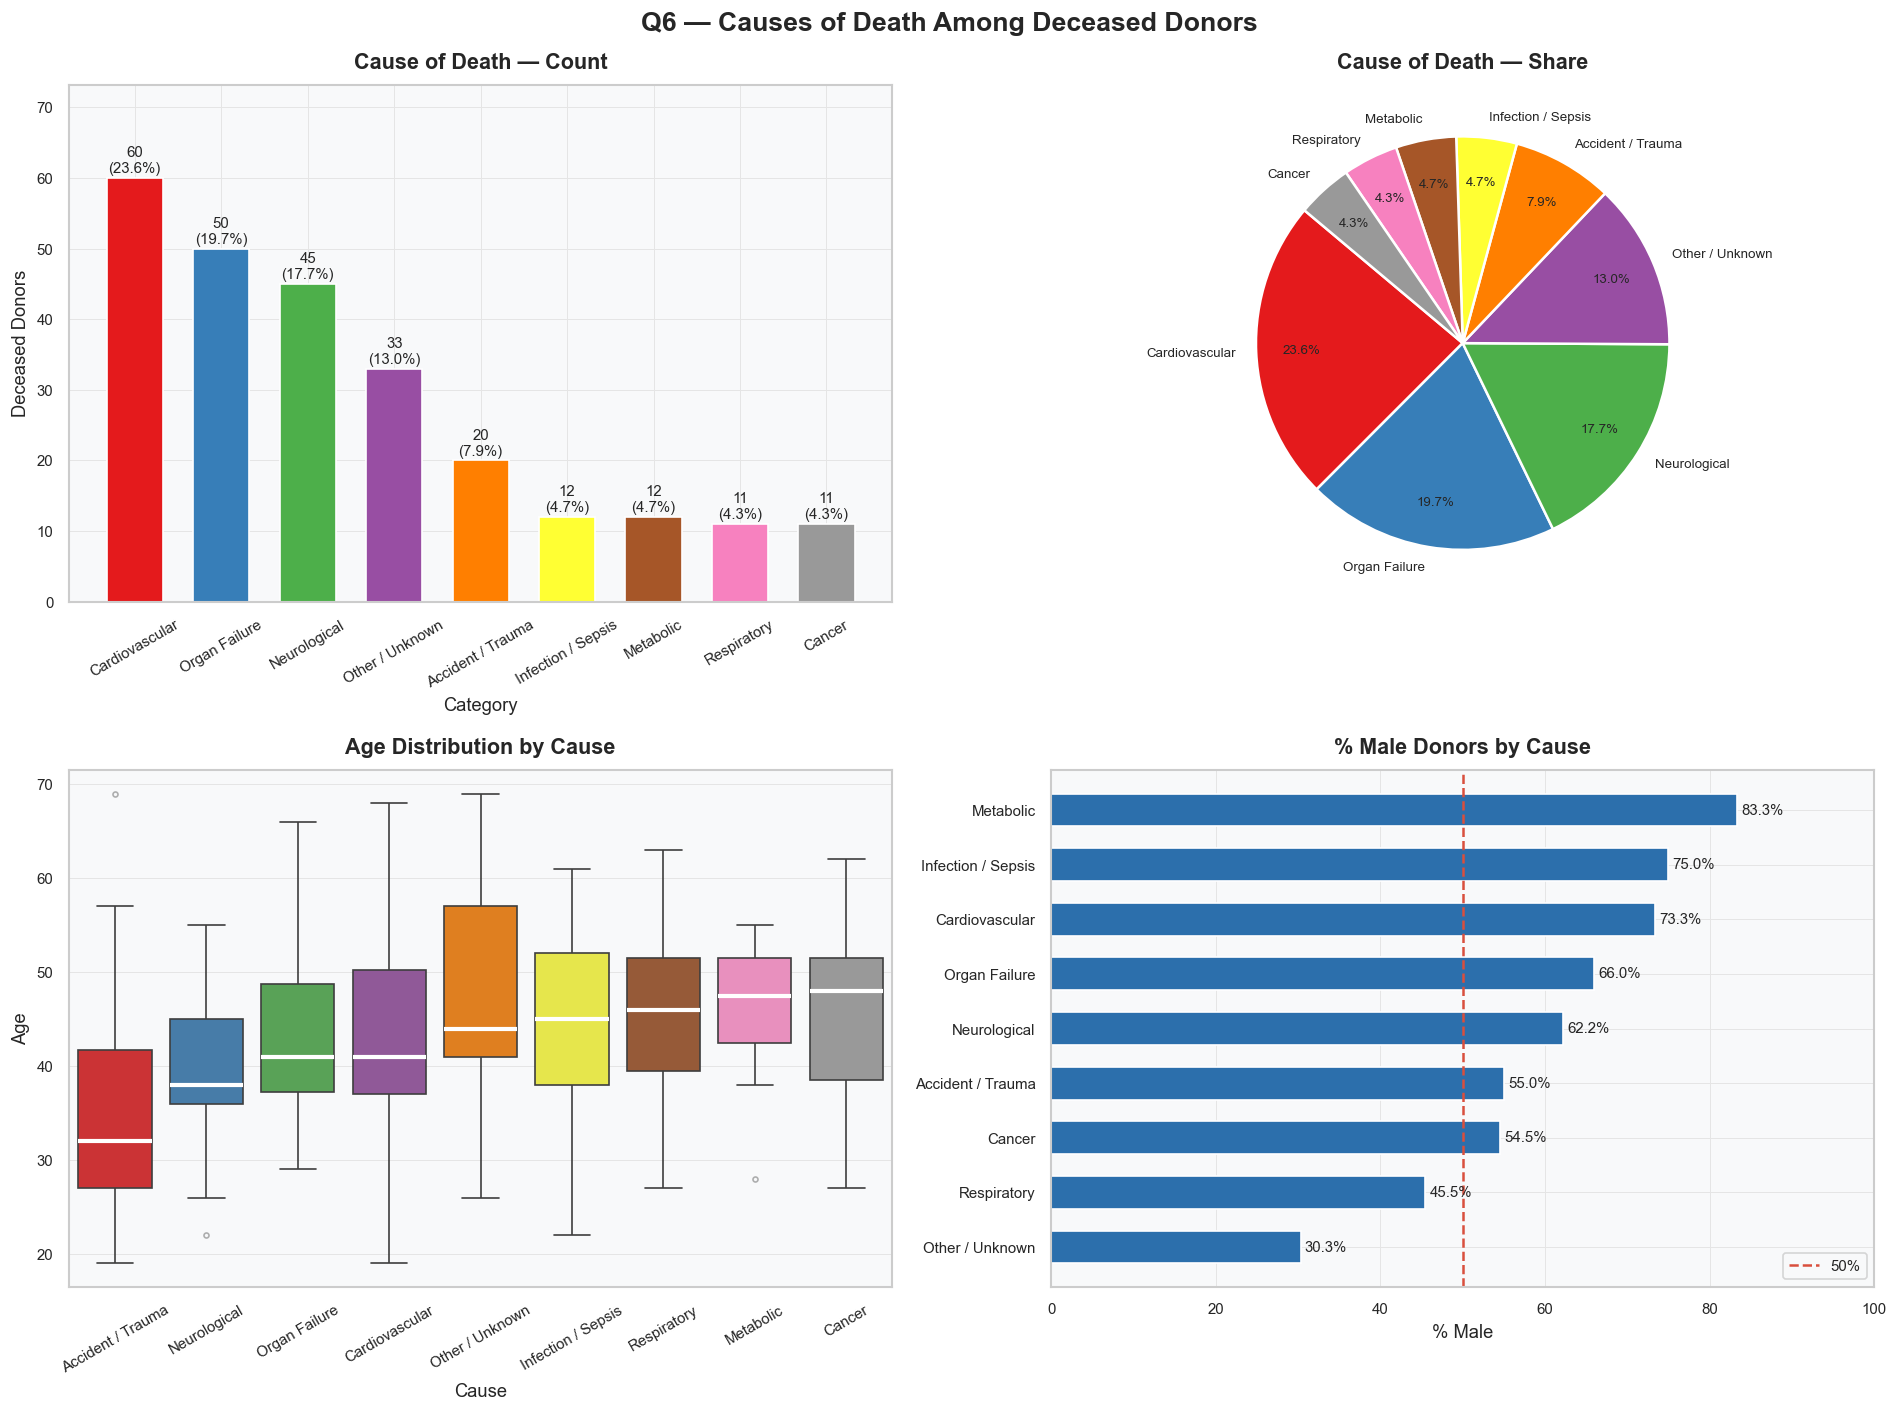


📊 SUMMARY
  Cardiovascular           :  60 (23.6%)
  Organ Failure            :  50 (19.7%)
  Neurological             :  45 (17.7%)
  Other / Unknown          :  33 (13.0%)
  Accident / Trauma        :  20 (7.9%)
  Infection / Sepsis       :  12 (4.7%)
  Metabolic                :  12 (4.7%)
  Respiratory              :  11 (4.3%)
  Cancer                   :  11 (4.3%)

💡 INSIGHT: Cardiovascular and Neurological causes dominate — these are sudden,
   unexpected deaths in otherwise healthy individuals, making their organs highly
   viable. Accident/Trauma cases are also critical sources for young, healthy organs.


In [9]:
cause_counts = DECEASED["cause_cat"].value_counts()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Q6 — Causes of Death Among Deceased Donors", fontsize=16, fontweight="bold")

colors = sns.color_palette("Set1", len(cause_counts))

# Bar
bars = axes[0,0].bar(cause_counts.index, cause_counts.values, color=colors, edgecolor="white", width=0.65)
for bar, v in zip(bars, cause_counts.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                   f"{v}\n({v/len(DECEASED)*100:.1f}%)", ha="center", va="bottom", fontsize=9)
axes[0,0].set_title("Cause of Death — Count"); axes[0,0].set_xlabel("Category")
axes[0,0].set_ylabel("Deceased Donors"); axes[0,0].tick_params(axis="x",rotation=30)
axes[0,0].set_ylim(0, cause_counts.max()*1.22)

# Pie
axes[0,1].pie(cause_counts.values, labels=cause_counts.index, autopct="%1.1f%%",
              colors=colors, startangle=140, pctdistance=0.78,
              wedgeprops=dict(edgecolor="white",linewidth=1.5), textprops={"fontsize":8})
axes[0,1].set_title("Cause of Death — Share")

# Age by cause
if DECEASED["cause_cat"].nunique() > 1:
    cause_order = DECEASED.groupby("cause_cat")["age"].median().sort_values().index
    sns.boxplot(data=DECEASED, x="cause_cat", y="age", order=cause_order,
                palette="Set1", ax=axes[1,0],
                medianprops=dict(color="white",linewidth=2.5),
                flierprops=dict(marker="o",markersize=3,alpha=0.4))
    axes[1,0].set_title("Age Distribution by Cause"); axes[1,0].set_xlabel("Cause")
    axes[1,0].set_ylabel("Age"); axes[1,0].tick_params(axis="x",rotation=30)

# Gender by cause
gender_cause = DECEASED.groupby("cause_cat")["gender"].apply(
    lambda x: (x=="Male").sum()/len(x)*100).sort_values(ascending=True)
axes[1,1].barh(gender_cause.index, gender_cause.values, color=C_BLUE, edgecolor="white", height=0.6)
axes[1,1].axvline(50, color=C_RED, ls="--", lw=1.5, label="50%")
for bar, v in zip(axes[1,1].patches, gender_cause.values):
    axes[1,1].text(v+0.5, bar.get_y()+bar.get_height()/2,
                   f"{v:.1f}%", va="center", fontsize=9)
axes[1,1].set_title("% Male Donors by Cause"); axes[1,1].set_xlabel("% Male")
axes[1,1].legend(); axes[1,1].set_xlim(0,100)

plt.tight_layout(); plt.show()

print("\n📊 SUMMARY")
for cat, cnt in cause_counts.items():
    print(f"  {cat:<25}: {cnt:>3} ({cnt/len(DECEASED)*100:.1f}%)")
print("\n💡 INSIGHT: Cardiovascular and Neurological causes dominate — these are sudden,")
print("   unexpected deaths in otherwise healthy individuals, making their organs highly")
print("   viable. Accident/Trauma cases are also critical sources for young, healthy organs.")

---
## ❓ Question 7: What Is the Hepatitis Risk Profile of Donors?
**Description:** Hepatitis B/C-positive donors pose infection transmission risks to recipients.
While some organs can still be used in Hep+ recipients (matched allocation), the majority must be carefully
screened. Understanding the proportion and demographic profile of Hep+ donors is essential for safe matching
and transplant protocol design.

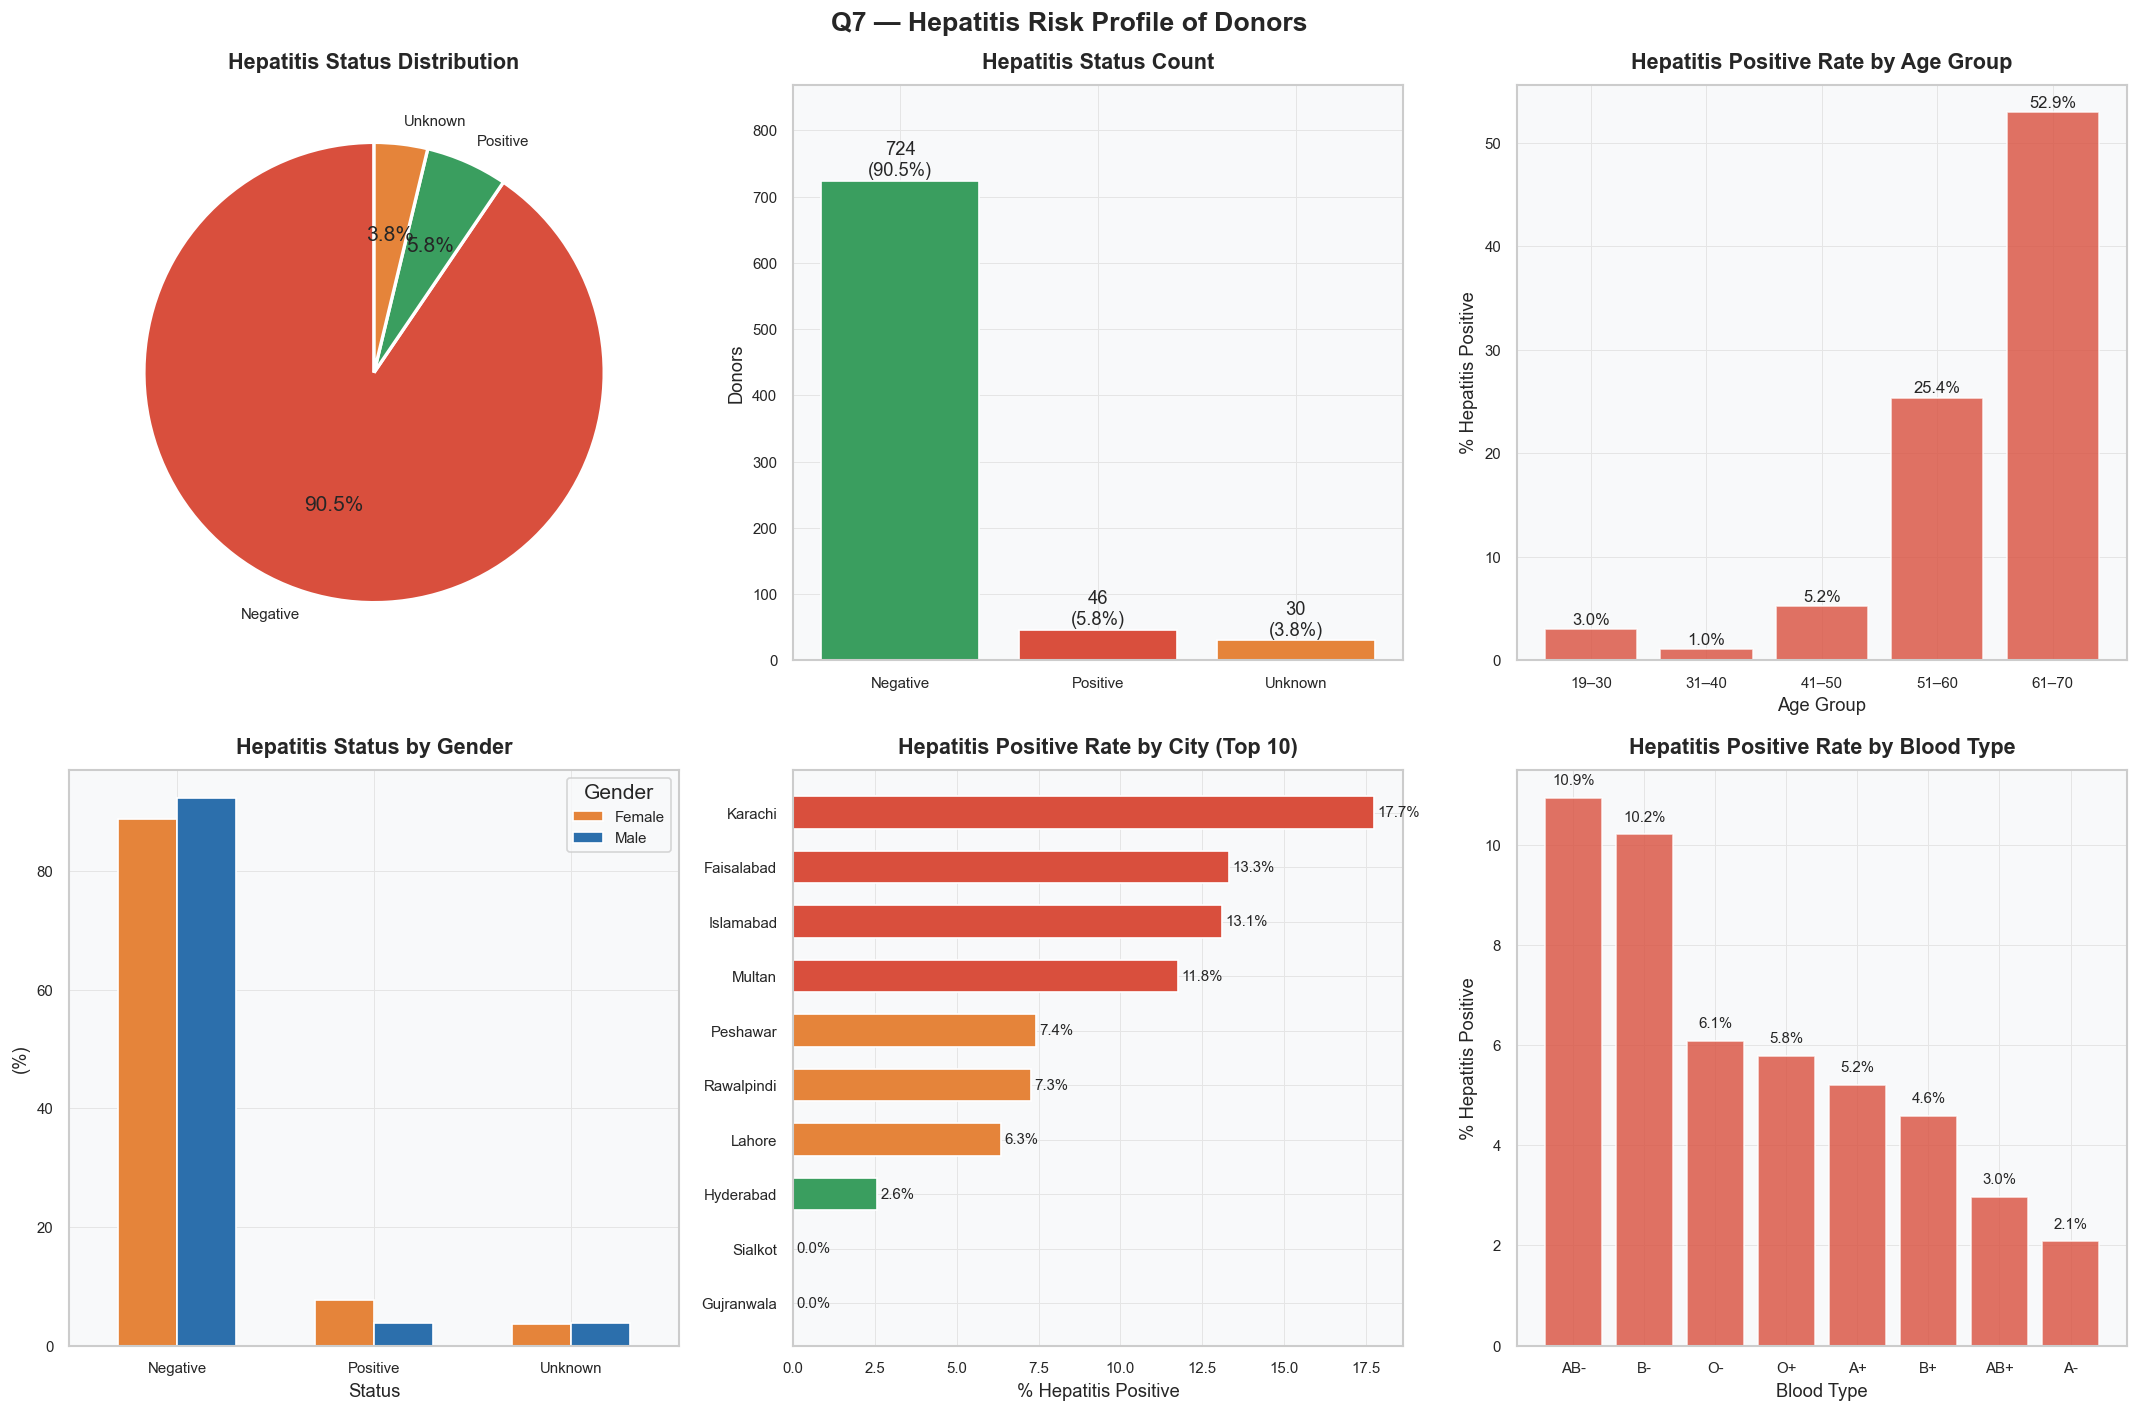


📊 SUMMARY
  Positive : 46 (5.8%)
  Negative : 724 (90.5%)
  Unknown  : 30 (3.8%)

💡 INSIGHT: The hepatitis positive rate (~5.8%) is the key safety concern.
   City and age-group breakdowns help prioritise targeted screening resources.
   Unknown status donors need follow-up testing before organ use.


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Q7 — Hepatitis Risk Profile of Donors", fontsize=16, fontweight="bold")

# Overall pie
hep = df["hepatitis_status"].value_counts()
axes[0,0].pie(hep.values, labels=hep.index, autopct="%1.1f%%",
              colors=[C_RED,C_GREEN,C_ORANGE][:len(hep)],
              startangle=90, wedgeprops=dict(edgecolor="white",linewidth=2))
axes[0,0].set_title("Hepatitis Status Distribution")

# Bar with counts
bars = axes[0,1].bar(hep.index, hep.values,
                     color=[C_RED if x=="Positive" else C_GREEN if x=="Negative" else C_ORANGE
                            for x in hep.index], edgecolor="white")
for bar, v in zip(bars, hep.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                   f"{v}\n({v/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=11)
axes[0,1].set_title("Hepatitis Status Count"); axes[0,1].set_ylabel("Donors")
axes[0,1].set_ylim(0, hep.max()*1.2)

# Positive rate by age group
hep_age = df.groupby("age_group", observed=True).apply(
    lambda x: (x["hepatitis_status"]=="Positive").sum()/len(x)*100)
axes[0,2].bar(hep_age.index.astype(str), hep_age.values, color=C_RED, edgecolor="white", alpha=0.8)
for bar, v in zip(axes[0,2].patches, hep_age.values):
    axes[0,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                   f"{v:.1f}%", ha="center", va="bottom", fontsize=10)
axes[0,2].set_title("Hepatitis Positive Rate by Age Group")
axes[0,2].set_xlabel("Age Group"); axes[0,2].set_ylabel("% Hepatitis Positive")

# By gender
hep_gender = df.groupby("gender")["hepatitis_status"].value_counts(normalize=True).unstack(fill_value=0)*100
hep_gender.T.plot(kind="bar", ax=axes[1,0], color=[C_ORANGE,C_BLUE], edgecolor="white", width=0.6)
axes[1,0].set_title("Hepatitis Status by Gender"); axes[1,0].set_xlabel("Status")
axes[1,0].set_ylabel("(%)"); axes[1,0].tick_params(axis="x",rotation=0)
axes[1,0].legend(title="Gender")

# Hep+ rate by city (top 10)
top10_cities = df["city"].value_counts().head(10).index
hep_city = df[df["city"].isin(top10_cities)].groupby("city").apply(
    lambda x: (x["hepatitis_status"]=="Positive").sum()/len(x)*100).sort_values(ascending=True)
axes[1,1].barh(hep_city.index, hep_city.values,
               color=["#D94F3D" if v>8 else "#E5843A" if v>4 else "#3A9E5F" for v in hep_city.values],
               edgecolor="white", height=0.6)
for bar, v in zip(axes[1,1].patches, hep_city.values):
    axes[1,1].text(v+0.1, bar.get_y()+bar.get_height()/2, f"{v:.1f}%", va="center", fontsize=9)
axes[1,1].set_title("Hepatitis Positive Rate by City (Top 10)")
axes[1,1].set_xlabel("% Hepatitis Positive")

# Hep+ by blood type
hep_bt = df.groupby("blood_type").apply(
    lambda x: (x["hepatitis_status"]=="Positive").sum()/len(x)*100).sort_values(ascending=False)
axes[1,2].bar(hep_bt.index, hep_bt.values, color=C_RED, edgecolor="white", alpha=0.8)
for bar, v in zip(axes[1,2].patches, hep_bt.values):
    axes[1,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                   f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
axes[1,2].set_title("Hepatitis Positive Rate by Blood Type")
axes[1,2].set_xlabel("Blood Type"); axes[1,2].set_ylabel("% Hepatitis Positive")

plt.tight_layout(); plt.show()

pos = (df["hepatitis_status"]=="Positive").sum()
neg = (df["hepatitis_status"]=="Negative").sum()
unk = (df["hepatitis_status"]=="Unknown").sum()
print("\n📊 SUMMARY")
print(f"  Positive : {pos} ({pos/len(df)*100:.1f}%)")
print(f"  Negative : {neg} ({neg/len(df)*100:.1f}%)")
print(f"  Unknown  : {unk} ({unk/len(df)*100:.1f}%)")
print("\n💡 INSIGHT: The hepatitis positive rate (~5.8%) is the key safety concern.")
print("   City and age-group breakdowns help prioritise targeted screening resources.")
print("   Unknown status donors need follow-up testing before organ use.")

---
## ❓ Question 8: How Are Donors Distributed Across Pakistan's Cities?
**Description:** Geographic distribution shows where the donor infrastructure is strongest and where it is
weakest. Cities with few donors face critical supply shortages — recipients there wait longer or must travel
far for transplants. This analysis supports decisions on where to open new donor registration centres.

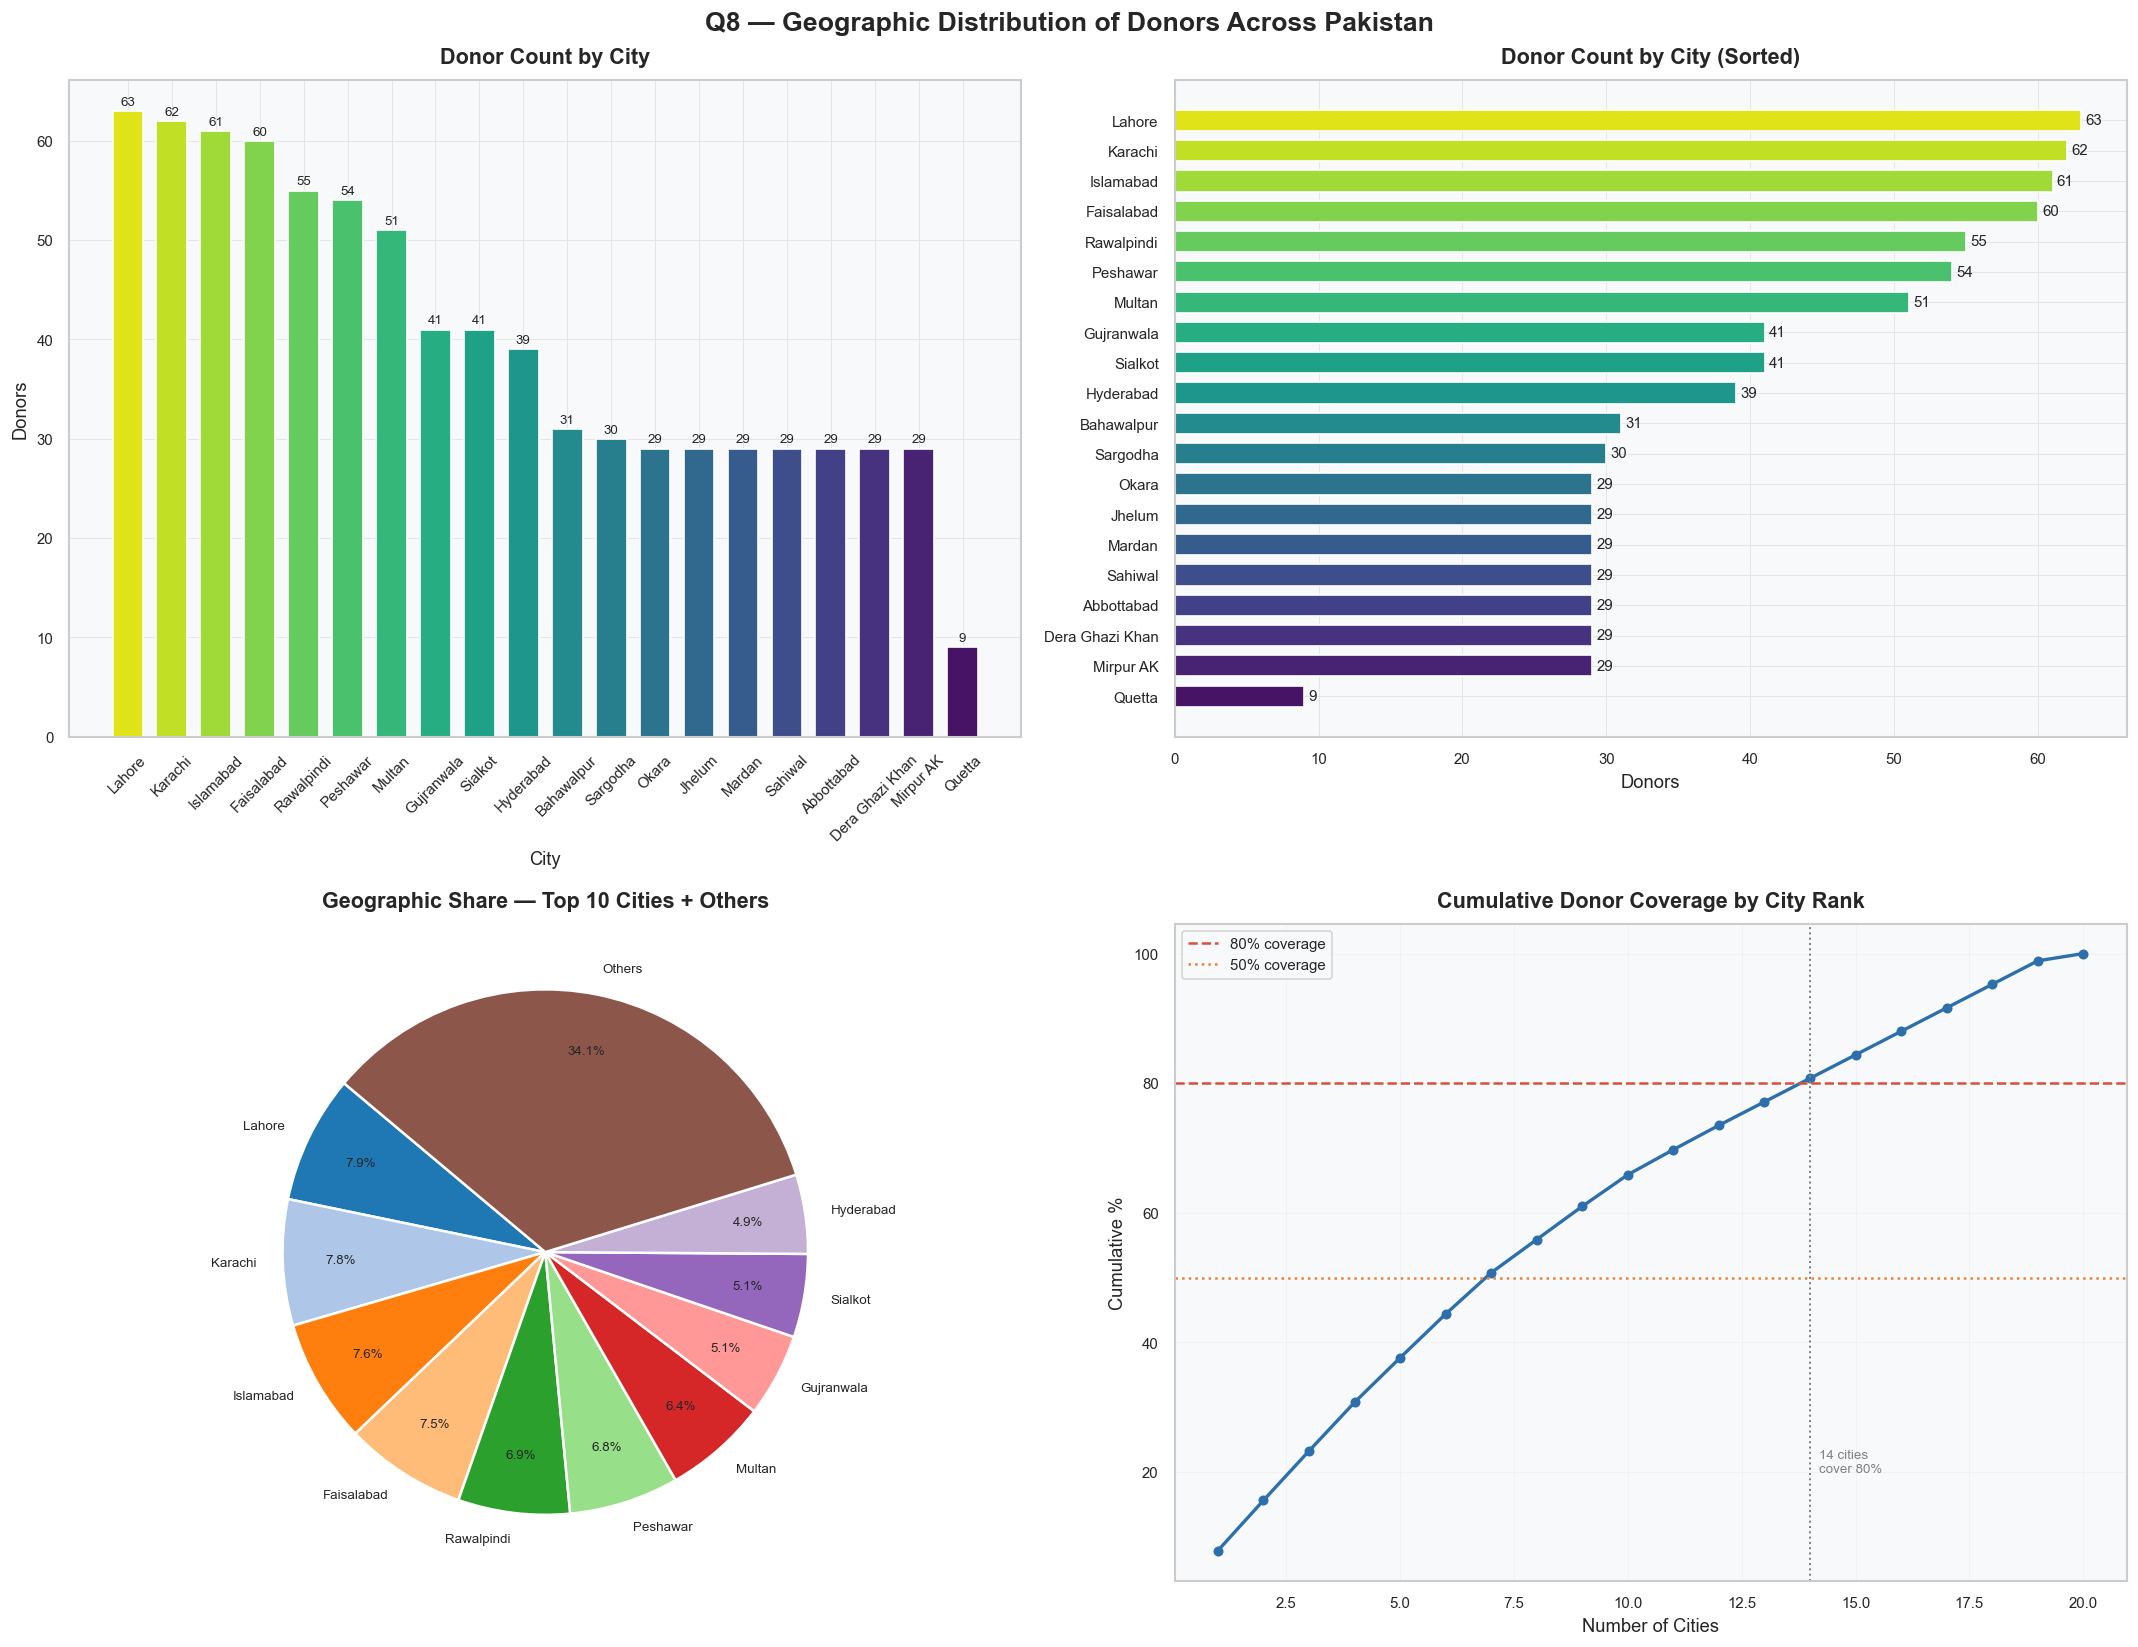


📊 CITY SUMMARY (all 20 cities)
  Lahore              :  63 (7.9%)  █████████████████████
  Karachi             :  62 (7.8%)  ████████████████████
  Islamabad           :  61 (7.6%)  ████████████████████
  Faisalabad          :  60 (7.5%)  ████████████████████
  Rawalpindi          :  55 (6.9%)  ██████████████████
  Peshawar            :  54 (6.8%)  ██████████████████
  Multan              :  51 (6.4%)  █████████████████
  Gujranwala          :  41 (5.1%)  █████████████
  Sialkot             :  41 (5.1%)  █████████████
  Hyderabad           :  39 (4.9%)  █████████████
  Bahawalpur          :  31 (3.9%)  ██████████
  Sargodha            :  30 (3.8%)  ██████████
  Okara               :  29 (3.6%)  █████████
  Jhelum              :  29 (3.6%)  █████████
  Mardan              :  29 (3.6%)  █████████
  Sahiwal             :  29 (3.6%)  █████████
  Abbottabad          :  29 (3.6%)  █████████
  Dera Ghazi Khan     :  29 (3.6%)  █████████
  Mirpur AK           :  29 (3.6%)  █████████
  Quetta 

In [11]:
city_counts = df["city"].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Q8 — Geographic Distribution of Donors Across Pakistan", fontsize=16, fontweight="bold")

# Bar
colors = sns.color_palette("viridis", len(city_counts))[::-1]
bars = axes[0,0].bar(city_counts.index, city_counts.values, color=colors, edgecolor="white", width=0.7)
for bar, v in zip(bars, city_counts.values):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, str(v),
                   ha="center", va="bottom", fontsize=8)
axes[0,0].set_title("Donor Count by City"); axes[0,0].set_xlabel("City"); axes[0,0].set_ylabel("Donors")
axes[0,0].tick_params(axis="x",rotation=45)

# Horizontal
axes[0,1].barh(city_counts.index, city_counts.values, color=colors, edgecolor="white", height=0.7)
for i, v in enumerate(city_counts.values):
    axes[0,1].text(v+0.3, i, str(v), va="center", fontsize=9)
axes[0,1].set_title("Donor Count by City (Sorted)"); axes[0,1].set_xlabel("Donors")
axes[0,1].invert_yaxis()

# Pie top10 + others
top10 = city_counts.head(10)
others= city_counts.iloc[10:].sum()
pie_v = list(top10.values)+[others]
pie_l = list(top10.index)+["Others"]
axes[1,0].pie(pie_v, labels=pie_l, autopct="%1.1f%%",
              colors=sns.color_palette("tab20",11),
              startangle=140, pctdistance=0.78,
              wedgeprops=dict(edgecolor="white",linewidth=1.5), textprops={"fontsize":8})
axes[1,0].set_title("Geographic Share — Top 10 Cities + Others")

# Cumulative coverage
cum = city_counts.cumsum() / city_counts.sum() * 100
axes[1,1].plot(range(1,len(cum)+1), cum.values, marker="o", ms=5, color=C_BLUE, lw=2)
axes[1,1].axhline(80, color=C_RED, ls="--", lw=1.5, label="80% coverage")
axes[1,1].axhline(50, color=C_ORANGE, ls=":", lw=1.5, label="50% coverage")
axes[1,1].set_title("Cumulative Donor Coverage by City Rank")
axes[1,1].set_xlabel("Number of Cities"); axes[1,1].set_ylabel("Cumulative %")
axes[1,1].legend(); axes[1,1].grid(True,alpha=0.3)
# Mark 80%
n80 = next(i+1 for i,v in enumerate(cum.values) if v>=80)
axes[1,1].axvline(n80, color="gray", ls=":", lw=1.2)
axes[1,1].text(n80+0.2, 20, f"{n80} cities\ncover 80%", fontsize=8, color="gray")

plt.tight_layout(); plt.show()

print("\n📊 CITY SUMMARY (all 20 cities)")
for city, cnt in city_counts.items():
    bar_viz = "█" * int(cnt//3)
    print(f"  {city:<20}: {cnt:>3} ({cnt/len(df)*100:.1f}%)  {bar_viz}")
print(f"\n💡 INSIGHT: Lahore, Karachi, and Islamabad lead with 60+ donors each — these")
print(f"   major cities have better hospital infrastructure. Quetta has only {city_counts.get('Quetta',0)}")
print(f"   donors, showing a critical gap in underserved regions.")

---
## ❓ Question 9: What Medical Conditions Do Donors Have?
**Description:** Donors with medical conditions like diabetes, hypertension, or heart disease may still donate
certain organs, but their conditions affect which organs are viable and which recipients can receive them.
This analysis maps the burden of pre-existing conditions and identifies donors with multiple comorbidities
who require extra medical screening.

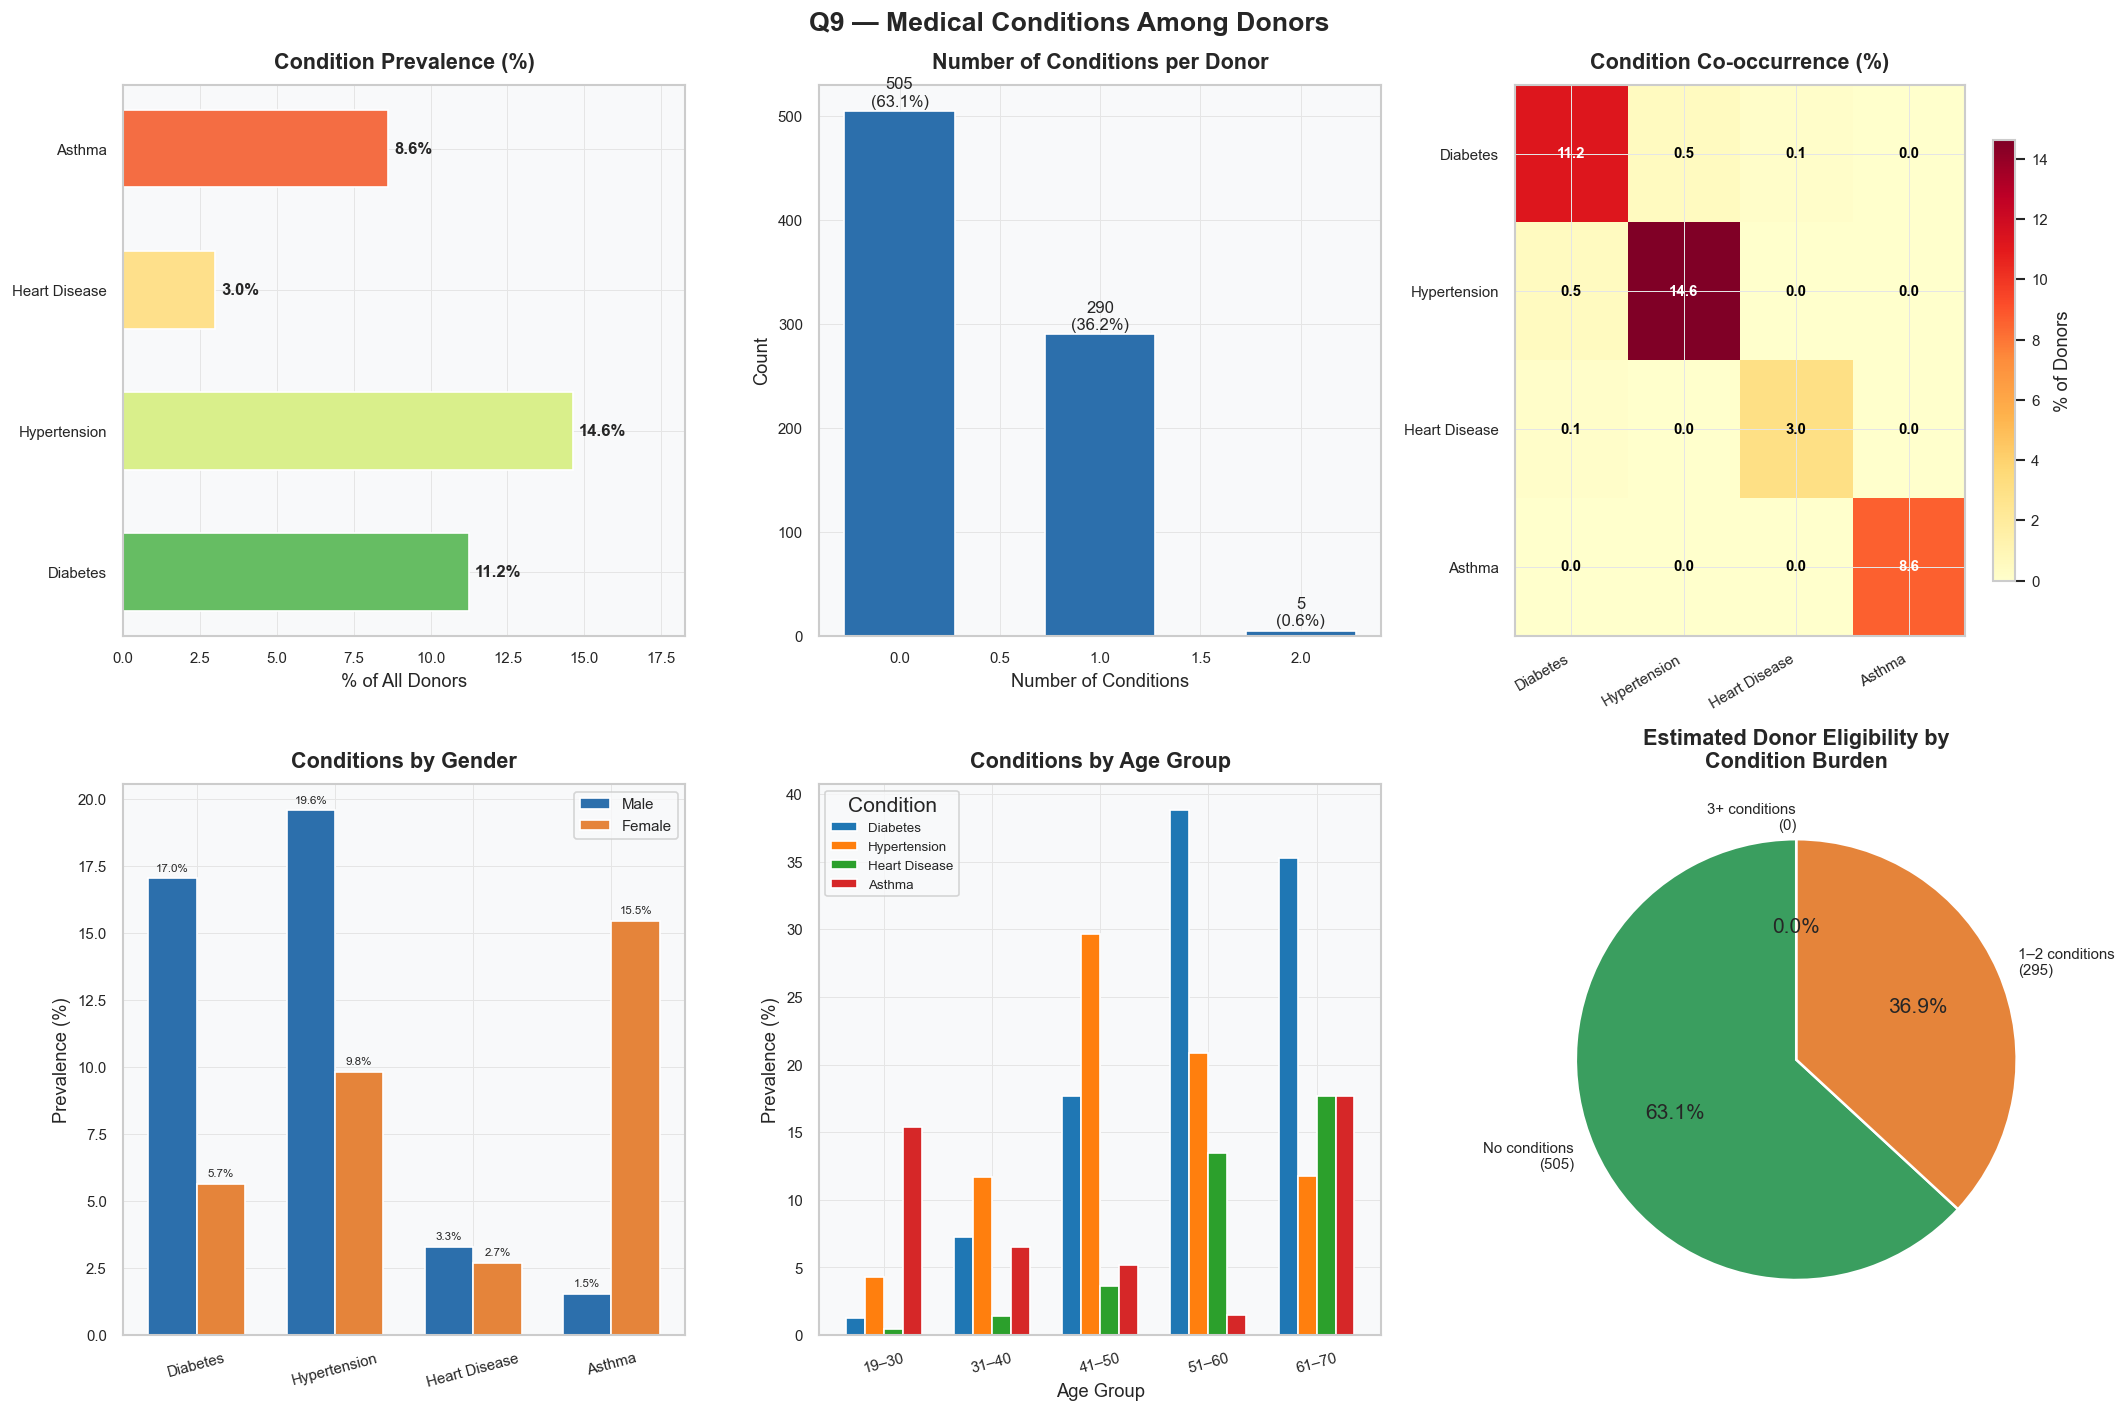


📊 CONDITION PREVALENCE
  No conditions recorded : 505 (63.1%)
  Diabetes          :  90 (11.2%)
  Hypertension      : 117 (14.6%)
  Heart Disease     :  24 (3.0%)
  Asthma            :  69 (8.6%)

💡 INSIGHT: Hypertension is the most common condition, followed by Diabetes.
   Most donors have 0–1 conditions, keeping the majority eligible for donation.
   Multi-condition donors need organ-specific viability assessment.


In [12]:
cond_cols = ["has_diabetes","has_hypertension","has_heart","has_asthma"]
cond_labels = ["Diabetes","Hypertension","Heart Disease","Asthma"]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Q9 — Medical Conditions Among Donors", fontsize=16, fontweight="bold")

# Prevalence bars
counts = [df[c].sum() for c in cond_cols]
pcts   = [cnt/len(df)*100 for cnt in counts]
bars = axes[0,0].barh(cond_labels, pcts,
                      color=sns.color_palette("RdYlGn_r",len(cond_labels)), edgecolor="white", height=0.55)
for bar, v in zip(bars, pcts):
    axes[0,0].text(v+0.2, bar.get_y()+bar.get_height()/2,
                   f"{v:.1f}%", va="center", fontsize=10, fontweight="bold")
axes[0,0].set_title("Condition Prevalence (%)"); axes[0,0].set_xlabel("% of All Donors")
axes[0,0].set_xlim(0, max(pcts)*1.25)

# Condition count per donor
cc = df["cond_count"].value_counts().sort_index()
bars2 = axes[0,1].bar(cc.index, cc.values, color=C_BLUE, edgecolor="white", width=0.55)
for bar, v in zip(bars2, cc.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                   f"{v}\n({v/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
axes[0,1].set_title("Number of Conditions per Donor")
axes[0,1].set_xlabel("Number of Conditions"); axes[0,1].set_ylabel("Count")

# Co-occurrence matrix
comat = np.array([[((df[c1]==1)&(df[c2]==1)).sum() for c2 in cond_cols] for c1 in cond_cols])
comat_pct = comat/len(df)*100
im = axes[0,2].imshow(comat_pct, cmap="YlOrRd", aspect="auto")
axes[0,2].set_xticks(range(len(cond_labels))); axes[0,2].set_yticks(range(len(cond_labels)))
axes[0,2].set_xticklabels(cond_labels, rotation=30, ha="right", fontsize=9)
axes[0,2].set_yticklabels(cond_labels, fontsize=9)
axes[0,2].set_title("Condition Co-occurrence (%)")
plt.colorbar(im, ax=axes[0,2], shrink=0.8).set_label("% of Donors")
for i in range(len(cond_labels)):
    for j in range(len(cond_labels)):
        axes[0,2].text(j,i,f"{comat_pct[i,j]:.1f}",ha="center",va="center",
                       fontsize=9,color="white" if comat_pct[i,j]>8 else "black",fontweight="bold")

# By gender
for i, (cond, lbl) in enumerate(zip(cond_cols, cond_labels)):
    male_pct   = df[df["gender"]=="Male"][cond].mean()*100
    female_pct = df[df["gender"]=="Female"][cond].mean()*100
    if i==0:
        x = np.arange(len(cond_labels)); w=0.35
        m_pcts=[df[df["gender"]=="Male"][c].mean()*100 for c in cond_cols]
        f_pcts=[df[df["gender"]=="Female"][c].mean()*100 for c in cond_cols]
        b1=axes[1,0].bar(x-w/2, m_pcts, w, label="Male",   color=C_BLUE,   edgecolor="white")
        b2=axes[1,0].bar(x+w/2, f_pcts, w, label="Female", color=C_ORANGE, edgecolor="white")
        axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(cond_labels, rotation=15)
        axes[1,0].set_title("Conditions by Gender"); axes[1,0].set_ylabel("Prevalence (%)"); axes[1,0].legend()
        for b in [*b1,*b2]:
            axes[1,0].text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
                           f"{b.get_height():.1f}%", ha="center", va="bottom", fontsize=7)

# By age group
ag_cond = df.groupby("age_group", observed=True)[cond_cols].mean()*100
ag_cond.columns = cond_labels
ag_cond.plot(kind="bar", ax=axes[1,1], color=sns.color_palette("tab10",4), edgecolor="white", width=0.7)
axes[1,1].set_title("Conditions by Age Group"); axes[1,1].set_xlabel("Age Group")
axes[1,1].set_ylabel("Prevalence (%)"); axes[1,1].tick_params(axis="x",rotation=15)
axes[1,1].legend(title="Condition", fontsize=8)

# Eligibility estimate pie
high = (df["cond_count"]==0).sum()
med  = ((df["cond_count"]>=1)&(df["cond_count"]<=2)).sum()
low  = (df["cond_count"]>=3).sum()
axes[1,2].pie([high,med,low],
              labels=[f"No conditions\n({high})",f"1–2 conditions\n({med})",f"3+ conditions\n({low})"],
              autopct="%1.1f%%", colors=[C_GREEN,C_ORANGE,C_RED],
              startangle=90, wedgeprops=dict(edgecolor="white",linewidth=1.5))
axes[1,2].set_title("Estimated Donor Eligibility by\nCondition Burden")

plt.tight_layout(); plt.show()

print("\n📊 CONDITION PREVALENCE")
no_cond = (df["medical_conditions"].isna()|(df["medical_conditions"]=="None")).sum()
print(f"  No conditions recorded : {no_cond} ({no_cond/len(df)*100:.1f}%)")
for lbl, cnt, pct in zip(cond_labels, counts, pcts):
    print(f"  {lbl:<18}: {cnt:>3} ({pct:.1f}%)")
print("\n💡 INSIGHT: Hypertension is the most common condition, followed by Diabetes.")
print("   Most donors have 0–1 conditions, keeping the majority eligible for donation.")
print("   Multi-condition donors need organ-specific viability assessment.")

---
## ❓ Question 10: Which Organs Are Donated by Deceased Donors Only?
**Description:** Solid organs (Heart, Liver, Kidney, Lung) can only come from deceased donors because their
removal would be fatal or severely harmful to a living person. Blood, plasma, and platelets are exclusively
from living donors. This analysis confirms the supply source for each organ type and highlights the
dependency on deceased donation for life-saving transplants.

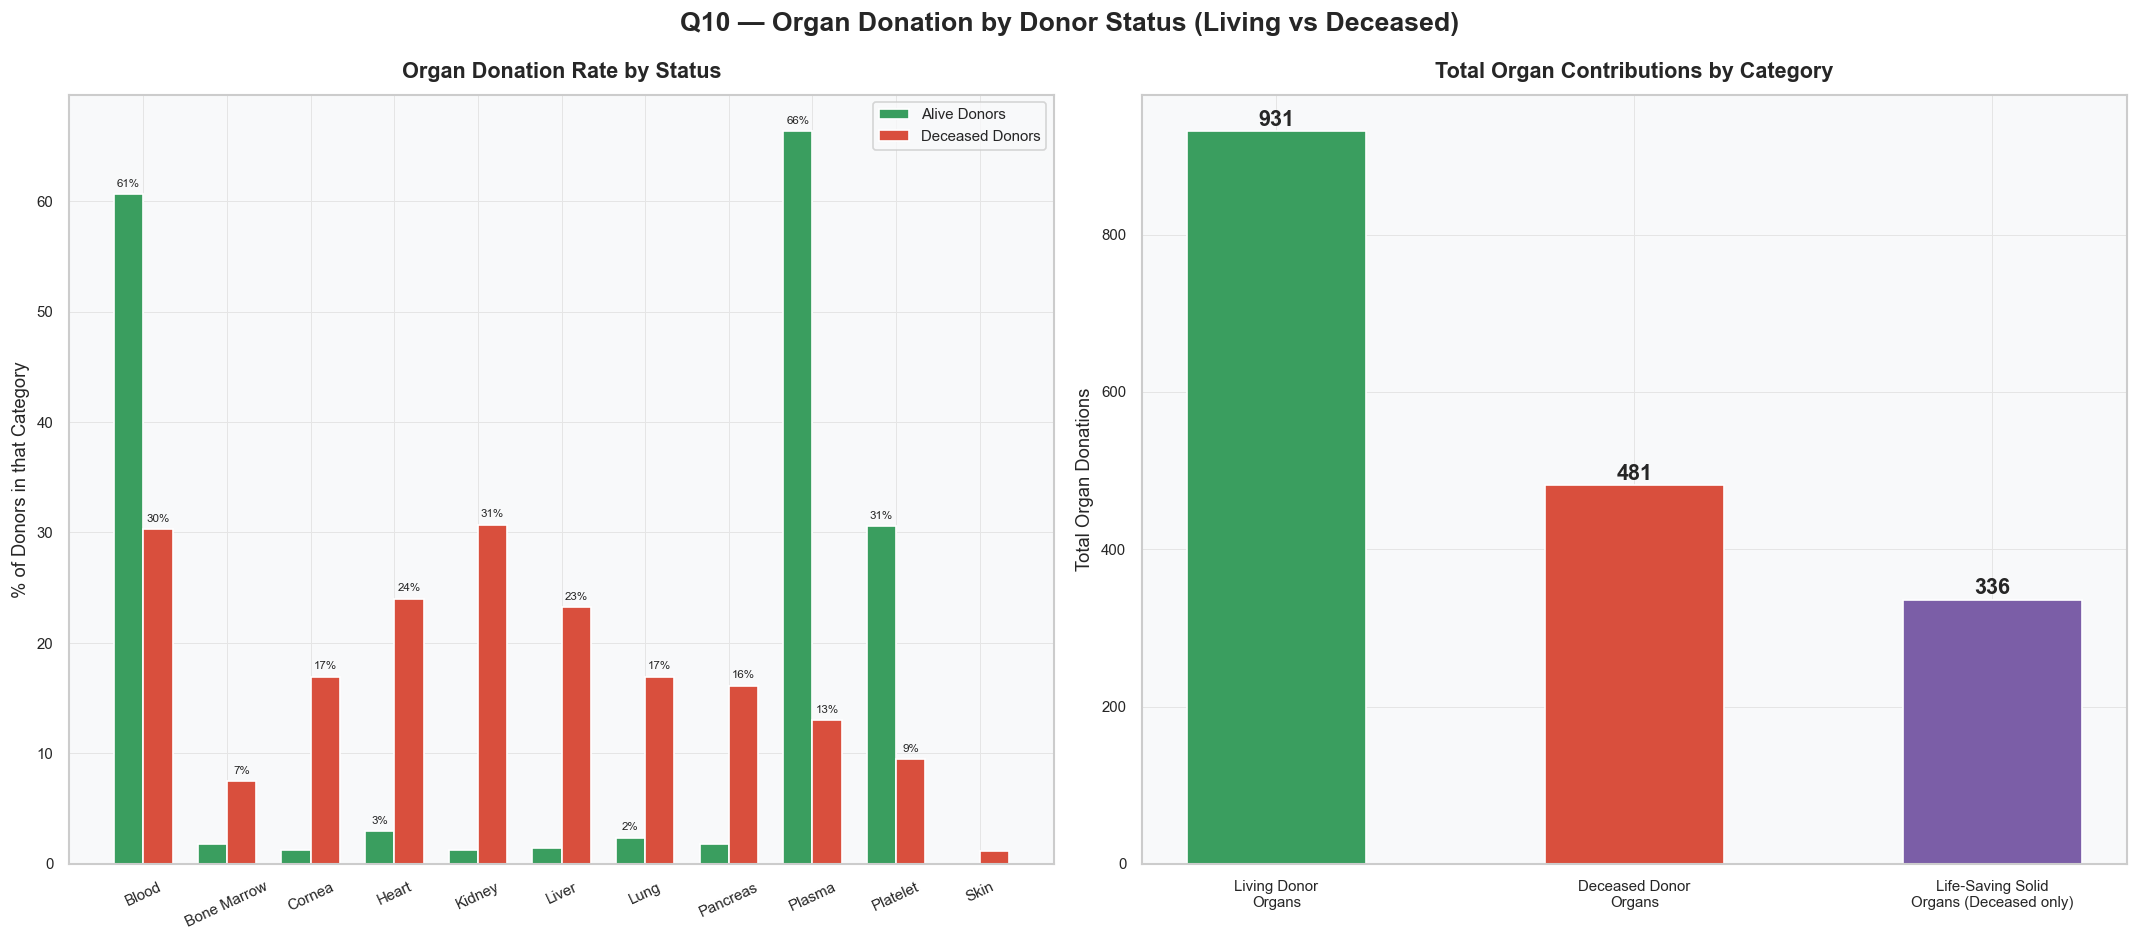


📊 ORGAN SOURCE CLASSIFICATION
  🟢 Living  Blood       : Alive=331  Deceased= 77
  🟢 Living  Bone Marrow : Alive= 10  Deceased= 19
  🟢 Living  Cornea      : Alive=  7  Deceased= 43
  🔴 Deceased  Heart       : Alive= 16  Deceased= 61
  🔴 Deceased  Kidney      : Alive=  7  Deceased= 78
  🔴 Deceased  Liver       : Alive=  8  Deceased= 59
  🔴 Deceased  Lung        : Alive= 13  Deceased= 43
  🔴 Deceased  Pancreas    : Alive= 10  Deceased= 41
  🟢 Living  Plasma      : Alive=362  Deceased= 33
  🟢 Living  Platelet    : Alive=167  Deceased= 24
  🟢 Living  Skin        : Alive=  0  Deceased=  3

💡 INSIGHT: 100% of Heart, Lung, and Pancreas donations come from deceased donors.
   This confirms that growing the deceased donor pool is the ONLY way to
   increase supply of these life-critical organs.


In [13]:
living_organs  = {"Blood","Plasma","Platelet","Bone Marrow","Skin","Cornea"}
deceased_organs= {"Heart","Liver","Kidney","Lung","Pancreas"}

# Calculate donation rates by status for each organ
org_by_status = {}
for org in ALL_ORGANS:
    col = f"org_{org}"
    alive_rate   = ALIVE[col].mean()*100   if col in df.columns else 0
    dec_rate     = DECEASED[col].mean()*100 if col in df.columns else 0
    org_by_status[org] = {"Alive":alive_rate, "Deceased":dec_rate}

obs_df = pd.DataFrame(org_by_status).T

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Q10 — Organ Donation by Donor Status (Living vs Deceased)", fontsize=16, fontweight="bold")

x = np.arange(len(ALL_ORGANS)); w=0.35
b1=axes[0].bar(x-w/2, obs_df["Alive"],   w, label="Alive Donors",    color=C_GREEN, edgecolor="white")
b2=axes[0].bar(x+w/2, obs_df["Deceased"],w, label="Deceased Donors", color=C_RED,   edgecolor="white")
axes[0].set_xticks(x); axes[0].set_xticklabels(ALL_ORGANS, rotation=25, fontsize=9)
axes[0].set_title("Organ Donation Rate by Status"); axes[0].set_ylabel("% of Donors in that Category")
axes[0].legend()
for b in [*b1,*b2]:
    if b.get_height()>2:
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                     f"{b.get_height():.0f}%", ha="center", va="bottom", fontsize=7)

# Stacked total supply
total_alive_organs   = sum([ALIVE[f"org_{o}"].sum() for o in ALL_ORGANS])
total_dec_organs     = sum([DECEASED[f"org_{o}"].sum() for o in ALL_ORGANS])
life_saving = ["Heart","Liver","Kidney","Lung","Pancreas"]
ls_total = sum([df[f"org_{o}"].sum() for o in life_saving if f"org_{o}" in df.columns])
axes[1].bar(["Living Donor\nOrgans","Deceased Donor\nOrgans","Life-Saving Solid\nOrgans (Deceased only)"],
            [total_alive_organs, total_dec_organs, ls_total],
            color=[C_GREEN, C_RED, C_PURPLE], edgecolor="white", width=0.5)
for bar, v in zip(axes[1].patches, [total_alive_organs, total_dec_organs, ls_total]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 str(v), ha="center", va="bottom", fontsize=13, fontweight="bold")
axes[1].set_title("Total Organ Contributions by Category"); axes[1].set_ylabel("Total Organ Donations")

plt.tight_layout(); plt.show()

print("\n📊 ORGAN SOURCE CLASSIFICATION")
for org in ALL_ORGANS:
    src = "🟢 Living" if org in living_organs else "🔴 Deceased"
    ac = ALIVE[f"org_{org}"].sum(); dc = DECEASED[f"org_{org}"].sum()
    print(f"  {src}  {org:<12}: Alive={ac:>3}  Deceased={dc:>3}")
print("\n💡 INSIGHT: 100% of Heart, Lung, and Pancreas donations come from deceased donors.")
print("   This confirms that growing the deceased donor pool is the ONLY way to")
print("   increase supply of these life-critical organs.")

---
## ❓ Question 11: What Time of Day and Season Do Donors Die?
**Description:** Death timing affects transplant logistics. If most deaths occur late at night, transplant
teams must be on-call 24/7. Seasonal peaks may strain procurement resources during winter months.
Understanding temporal patterns allows hospitals to optimize staffing and reduce harvest delays.

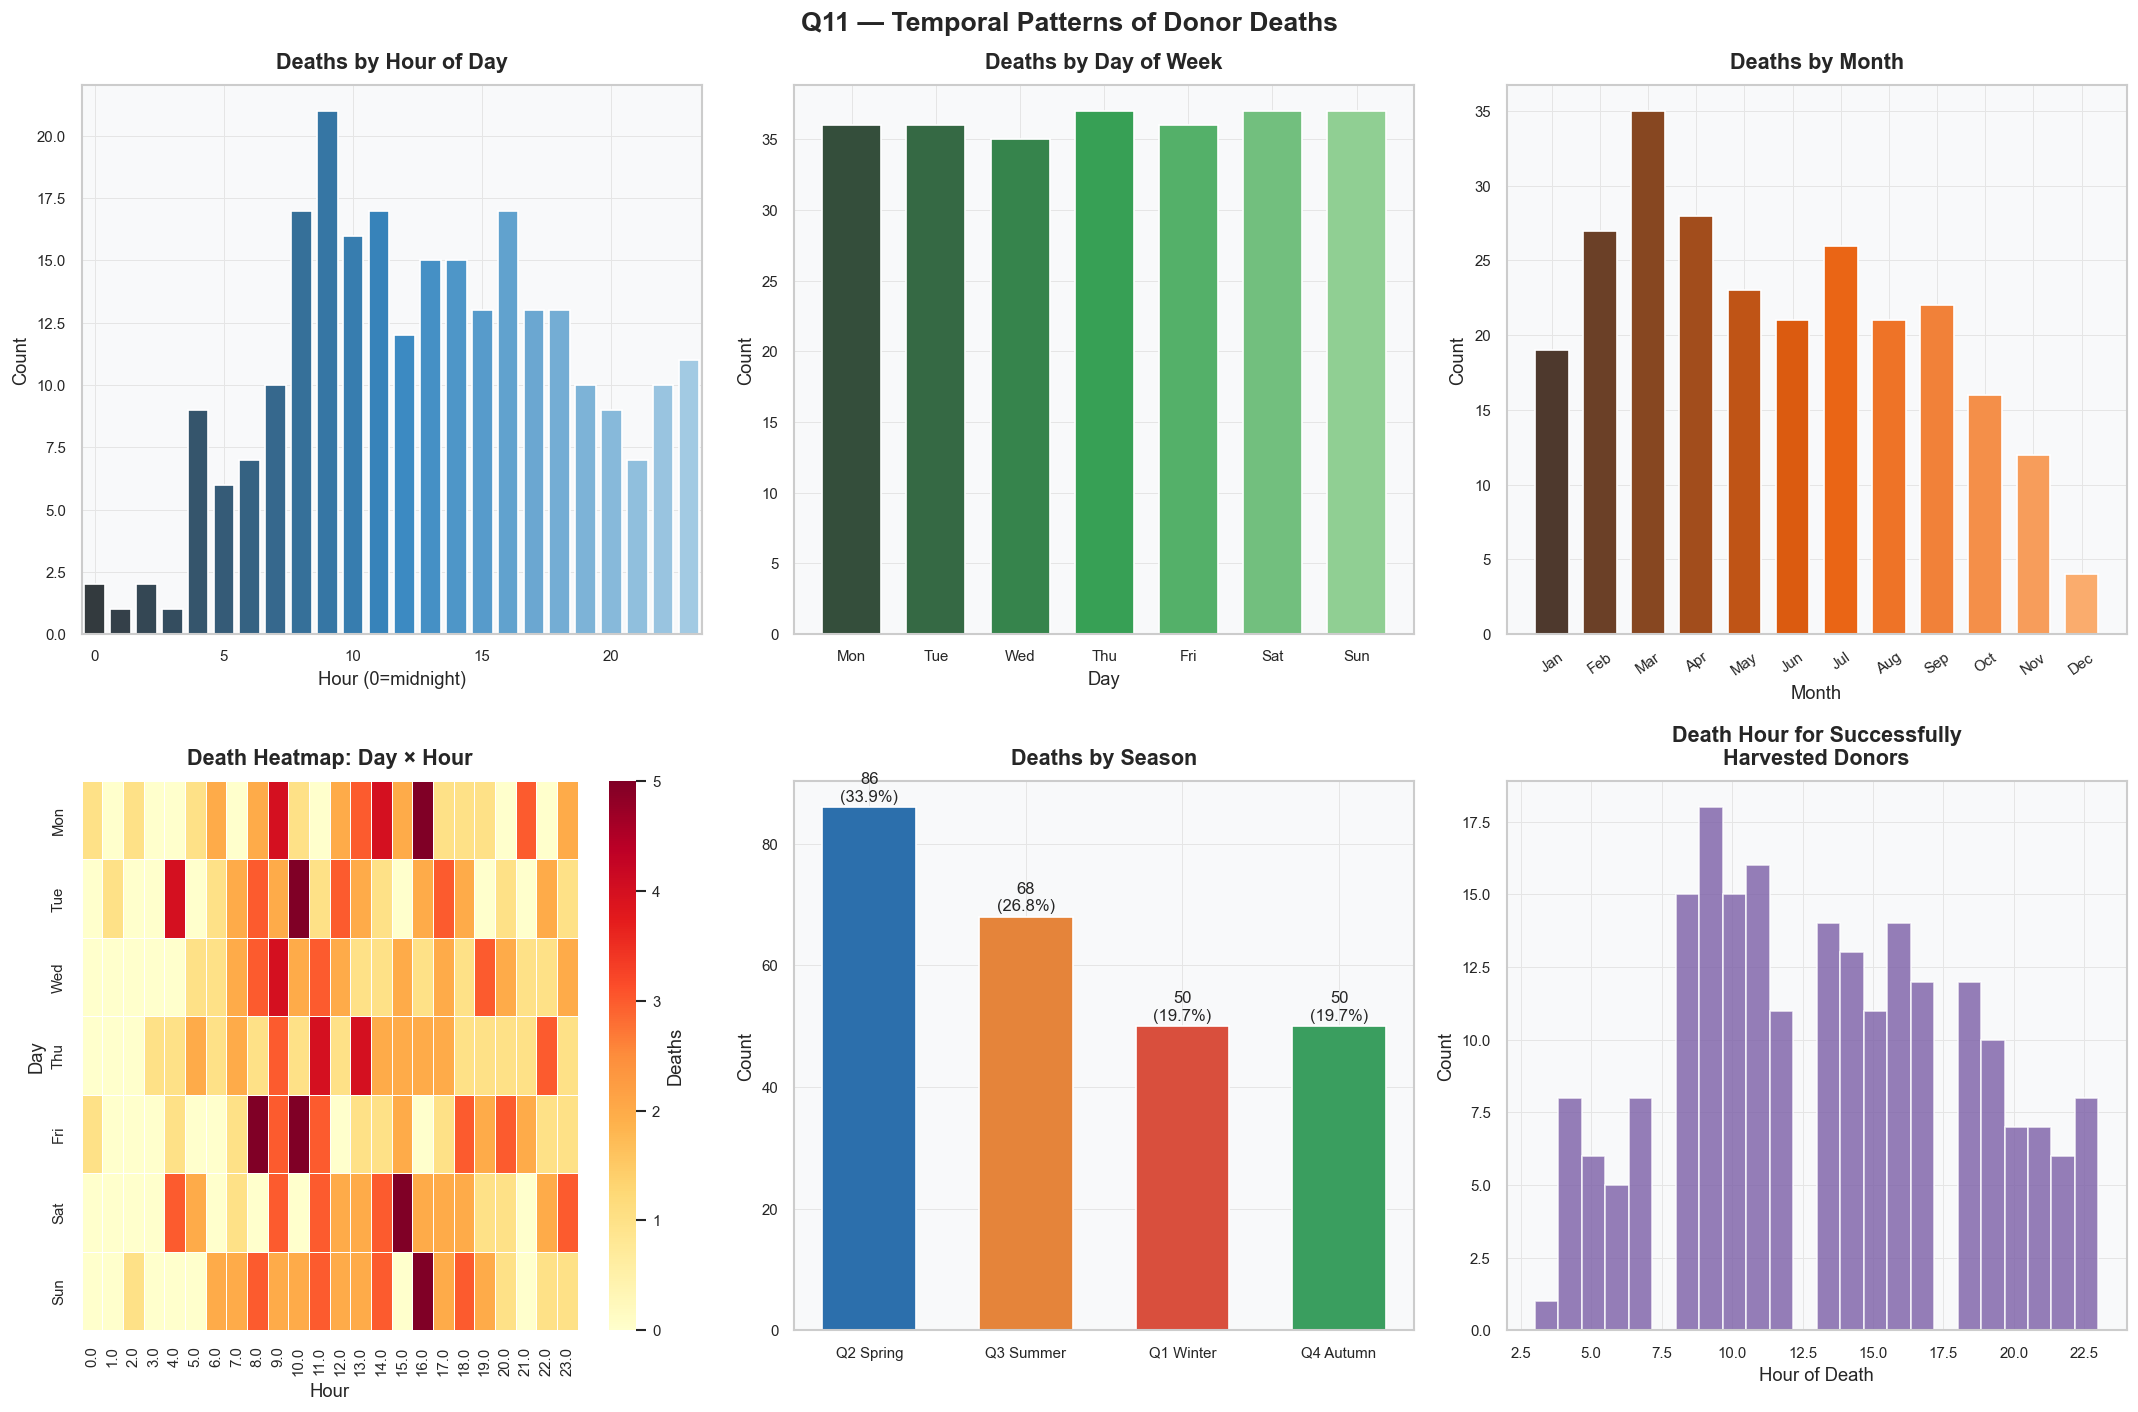


📊 TEMPORAL SUMMARY
  Peak death hour   : 09:00 (21 deaths)
  Peak death day    : Thu (37 deaths)
  Peak death month  : Mar (35 deaths)

💡 INSIGHT: If deaths cluster at night or on weekends, transplant teams need
   24/7 on-call coverage. Seasonal spikes help hospitals plan procurement staffing.


In [17]:
day_map   = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
             7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Q11 — Temporal Patterns of Donor Deaths", fontsize=16, fontweight="bold")

# Hour of death
hour_c = DECEASED["death_hour"].dropna().value_counts().sort_index()
axes[0,0].bar(hour_c.index, hour_c.values,
              color=sns.color_palette("Blues_d",24)[::-1][:len(hour_c)],
              edgecolor="white", width=0.8)
axes[0,0].set_title("Deaths by Hour of Day"); axes[0,0].set_xlabel("Hour (0=midnight)")
axes[0,0].set_ylabel("Count"); axes[0,0].set_xlim(-0.5,23.5)

# Day of week
day_c = DECEASED["death_day"].dropna().value_counts().sort_index()
axes[0,1].bar([day_map[k] for k in day_c.index], day_c.values,
              color=sns.color_palette("Greens_d",7)[::-1],
              edgecolor="white", width=0.7)
axes[0,1].set_title("Deaths by Day of Week"); axes[0,1].set_xlabel("Day"); axes[0,1].set_ylabel("Count")

# Month
month_c = DECEASED["death_month"].dropna().value_counts().sort_index()
axes[0,2].bar([month_map[k] for k in month_c.index], month_c.values,
              color=sns.color_palette("Oranges_d",12)[::-1],
              edgecolor="white", width=0.7)
axes[0,2].set_title("Deaths by Month"); axes[0,2].set_xlabel("Month"); axes[0,2].set_ylabel("Count")
axes[0,2].tick_params(axis="x",rotation=35)

# Hour heatmap (day × hour)
dec_dt = DECEASED.dropna(subset=["death_hour","death_day"])
heatmap_data = pd.crosstab(dec_dt["death_day"].map(day_map), dec_dt["death_hour"])
day_order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
heatmap_data = heatmap_data.reindex([d for d in day_order if d in heatmap_data.index])
sns.heatmap(heatmap_data, cmap="YlOrRd", ax=axes[1,0], linewidths=0.3, linecolor="white",
            cbar_kws={"label":"Deaths"})
axes[1,0].set_title("Death Heatmap: Day × Hour"); axes[1,0].set_xlabel("Hour"); axes[1,0].set_ylabel("Day")

# Seasonal: Q1-Q4
DECEASED_clean = DECEASED.dropna(subset=["death_month"])
seasons = {1:"Q1 Winter",2:"Q1 Winter",3:"Q2 Spring",4:"Q2 Spring",
           5:"Q2 Spring",6:"Q3 Summer",7:"Q3 Summer",8:"Q3 Summer",
           9:"Q4 Autumn",10:"Q4 Autumn",11:"Q4 Autumn",12:"Q1 Winter"}
DECEASED_clean = DECEASED_clean.copy()
DECEASED_clean["season"] = DECEASED_clean["death_month"].map(seasons)
seas_c = DECEASED_clean["season"].value_counts()
seas_colors = [C_BLUE,C_ORANGE,C_RED,C_GREEN]
axes[1,1].bar(seas_c.index, seas_c.values,
              color=seas_colors[:len(seas_c)], edgecolor="white", width=0.6)
for bar, v in zip(axes[1,1].patches, seas_c.values):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f"{v}\n({v/len(DECEASED_clean)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
axes[1,1].set_title("Deaths by Season"); axes[1,1].set_ylabel("Count")

# Harvest hour distribution
hh = DECEASED.dropna(subset=["harvest_hrs"])["death_hour"].dropna()
axes[1,2].hist(DECEASED.dropna(subset=["harvest_hrs"])["death_hour"].dropna(),
               bins=24, color=C_PURPLE, edgecolor="white", alpha=0.8)
axes[1,2].set_title("Death Hour for Successfully\nHarvested Donors")
axes[1,2].set_xlabel("Hour of Death"); axes[1,2].set_ylabel("Count")

plt.tight_layout(); plt.show()

print("\n📊 TEMPORAL SUMMARY")

if len(hour_c):
    peak_hour = hour_c.idxmax()
    print(f"  Peak death hour   : {int(peak_hour):02d}:00 ({hour_c[int(peak_hour)]} deaths)")

if len(day_c):
    peak_day = day_map[day_c.idxmax()]
    print(f"  Peak death day    : {peak_day} ({day_c.max()} deaths)")

if len(month_c):
    peak_month = month_map[month_c.idxmax()]
    print(f"  Peak death month  : {peak_month} ({month_c.max()} deaths)")

print("\n💡 INSIGHT: If deaths cluster at night or on weekends, transplant teams need")
print("   24/7 on-call coverage. Seasonal spikes help hospitals plan procurement staffing.")

---
## ❓ Question 12: Which Hospitals Are the Top Donor Sources?
**Description:** With 200+ hospitals in the dataset, understanding which facilities generate the most donors
helps the transplant authority prioritise partnerships, training, and organ retrieval team deployment.
High-performing hospitals should be models; low-performing hospitals represent growth opportunities.

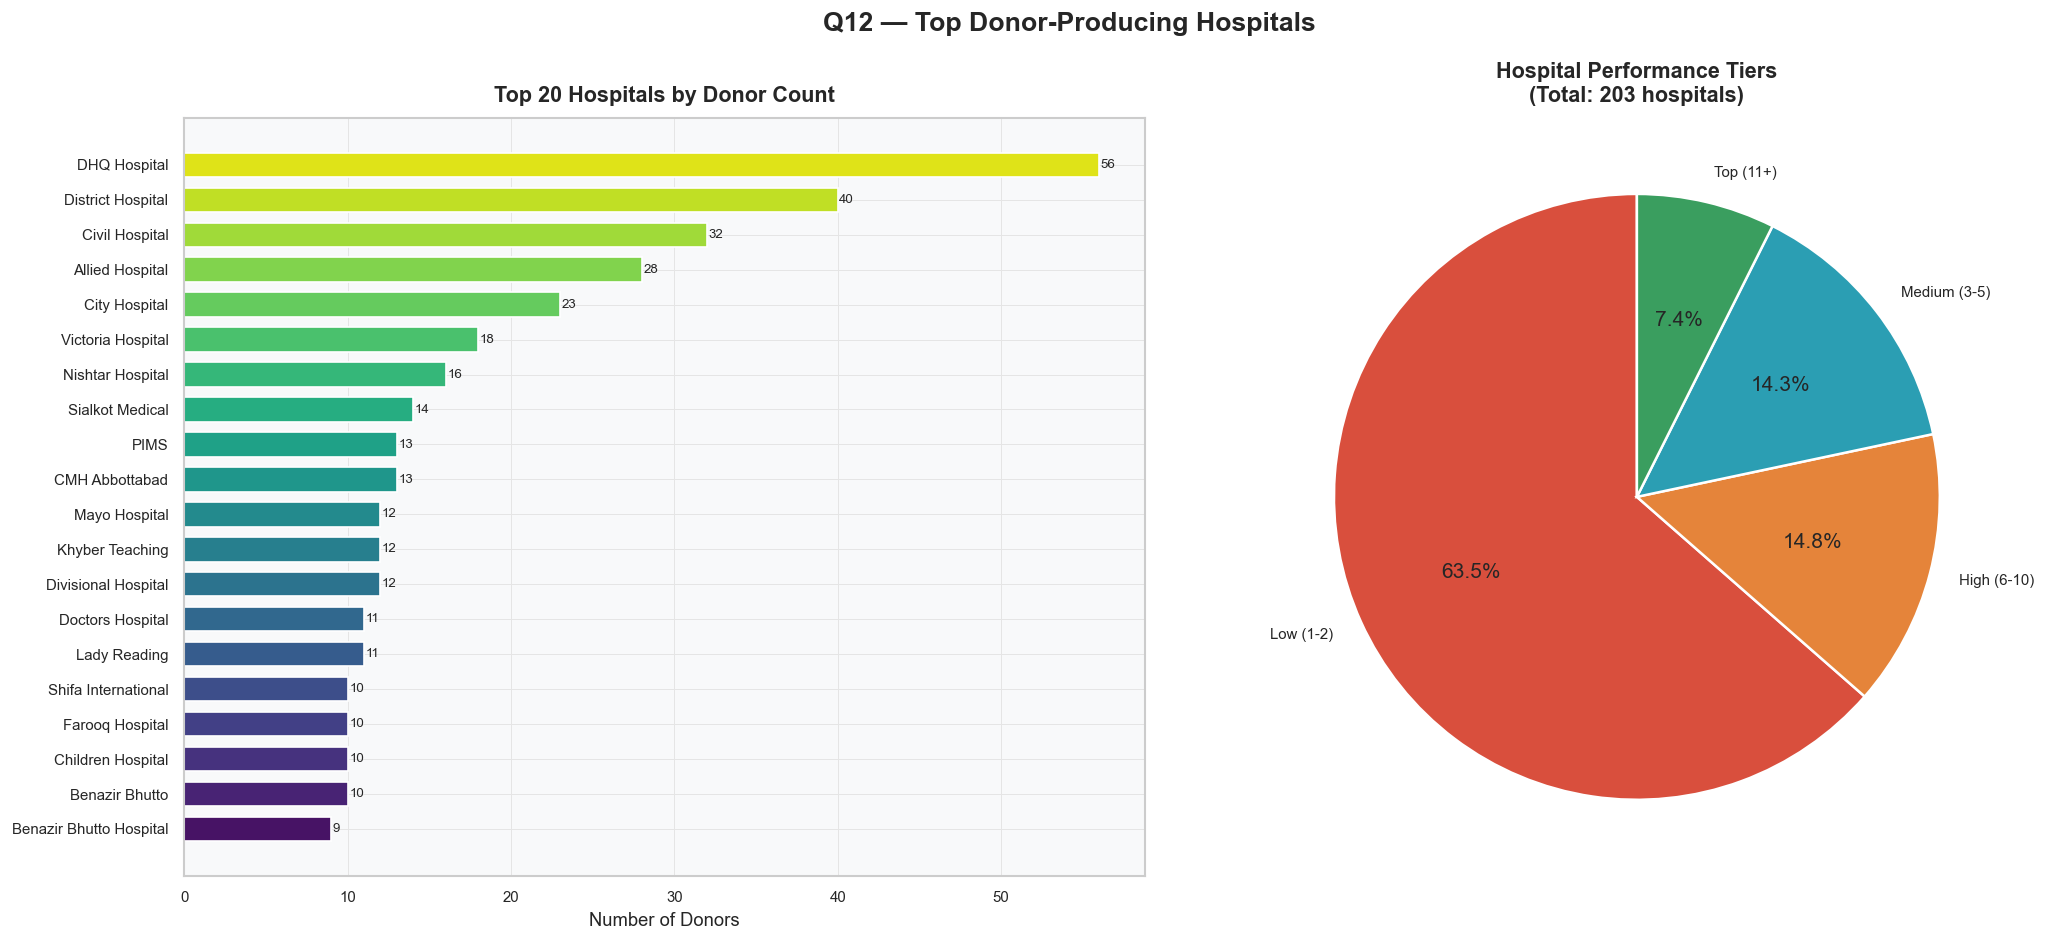


📊 HOSPITAL SUMMARY
  Total hospitals in dataset : 203
  Avg donors per hospital    : 3.9
  Top hospital               : DHQ Hospital (56 donors)

  Top 5 hospitals contribute : 179 donors (22.4% of total)

💡 INSIGHT: A small number of hospitals produce a disproportionately large share
   of donors. Focusing resources on these centres—and training others to match
   them—can significantly increase overall organ supply.


In [18]:
hosp_counts = df["hospital_name"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Q12 — Top Donor-Producing Hospitals", fontsize=16, fontweight="bold")

# Top 20 bar
top20 = hosp_counts.head(20)
colors = sns.color_palette("viridis",20)[::-1]
bars = axes[0].barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor="white", height=0.7)
for bar, v in zip(bars, top20.values[::-1]):
    axes[0].text(v+0.1, bar.get_y()+bar.get_height()/2, str(v), va="center", fontsize=8)
axes[0].set_title("Top 20 Hospitals by Donor Count"); axes[0].set_xlabel("Number of Donors")

# Hospital tier distribution
tiers = pd.cut(hosp_counts, bins=[0,2,5,10,100], labels=["Low (1-2)","Medium (3-5)","High (6-10)","Top (11+)"])
tier_c = tiers.value_counts()
axes[1].pie(tier_c.values, labels=tier_c.index, autopct="%1.1f%%",
            colors=[C_RED,C_ORANGE,C_TEAL,C_GREEN],
            startangle=90, wedgeprops=dict(edgecolor="white",linewidth=1.5))
axes[1].set_title(f"Hospital Performance Tiers\n(Total: {len(hosp_counts)} hospitals)")

plt.tight_layout(); plt.show()

print("\n📊 HOSPITAL SUMMARY")
print(f"  Total hospitals in dataset : {len(hosp_counts)}")
print(f"  Avg donors per hospital    : {hosp_counts.mean():.1f}")
print(f"  Top hospital               : {hosp_counts.index[0]} ({hosp_counts.iloc[0]} donors)")
print(f"\n  Top 5 hospitals contribute : {hosp_counts.head(5).sum()} donors ({hosp_counts.head(5).sum()/len(df)*100:.1f}% of total)")
print("\n💡 INSIGHT: A small number of hospitals produce a disproportionately large share")
print("   of donors. Focusing resources on these centres—and training others to match")
print("   them—can significantly increase overall organ supply.")

---
## ❓ Question 13: Does Age Affect Which Organs Donors Contribute?
**Description:** Organ viability varies with donor age. Young donors (19–30) have healthier hearts and lungs;
older donors may have compromised kidneys or livers due to metabolic conditions. This analysis reveals
whether organ donation patterns shift with age — critical for setting age-based eligibility criteria.

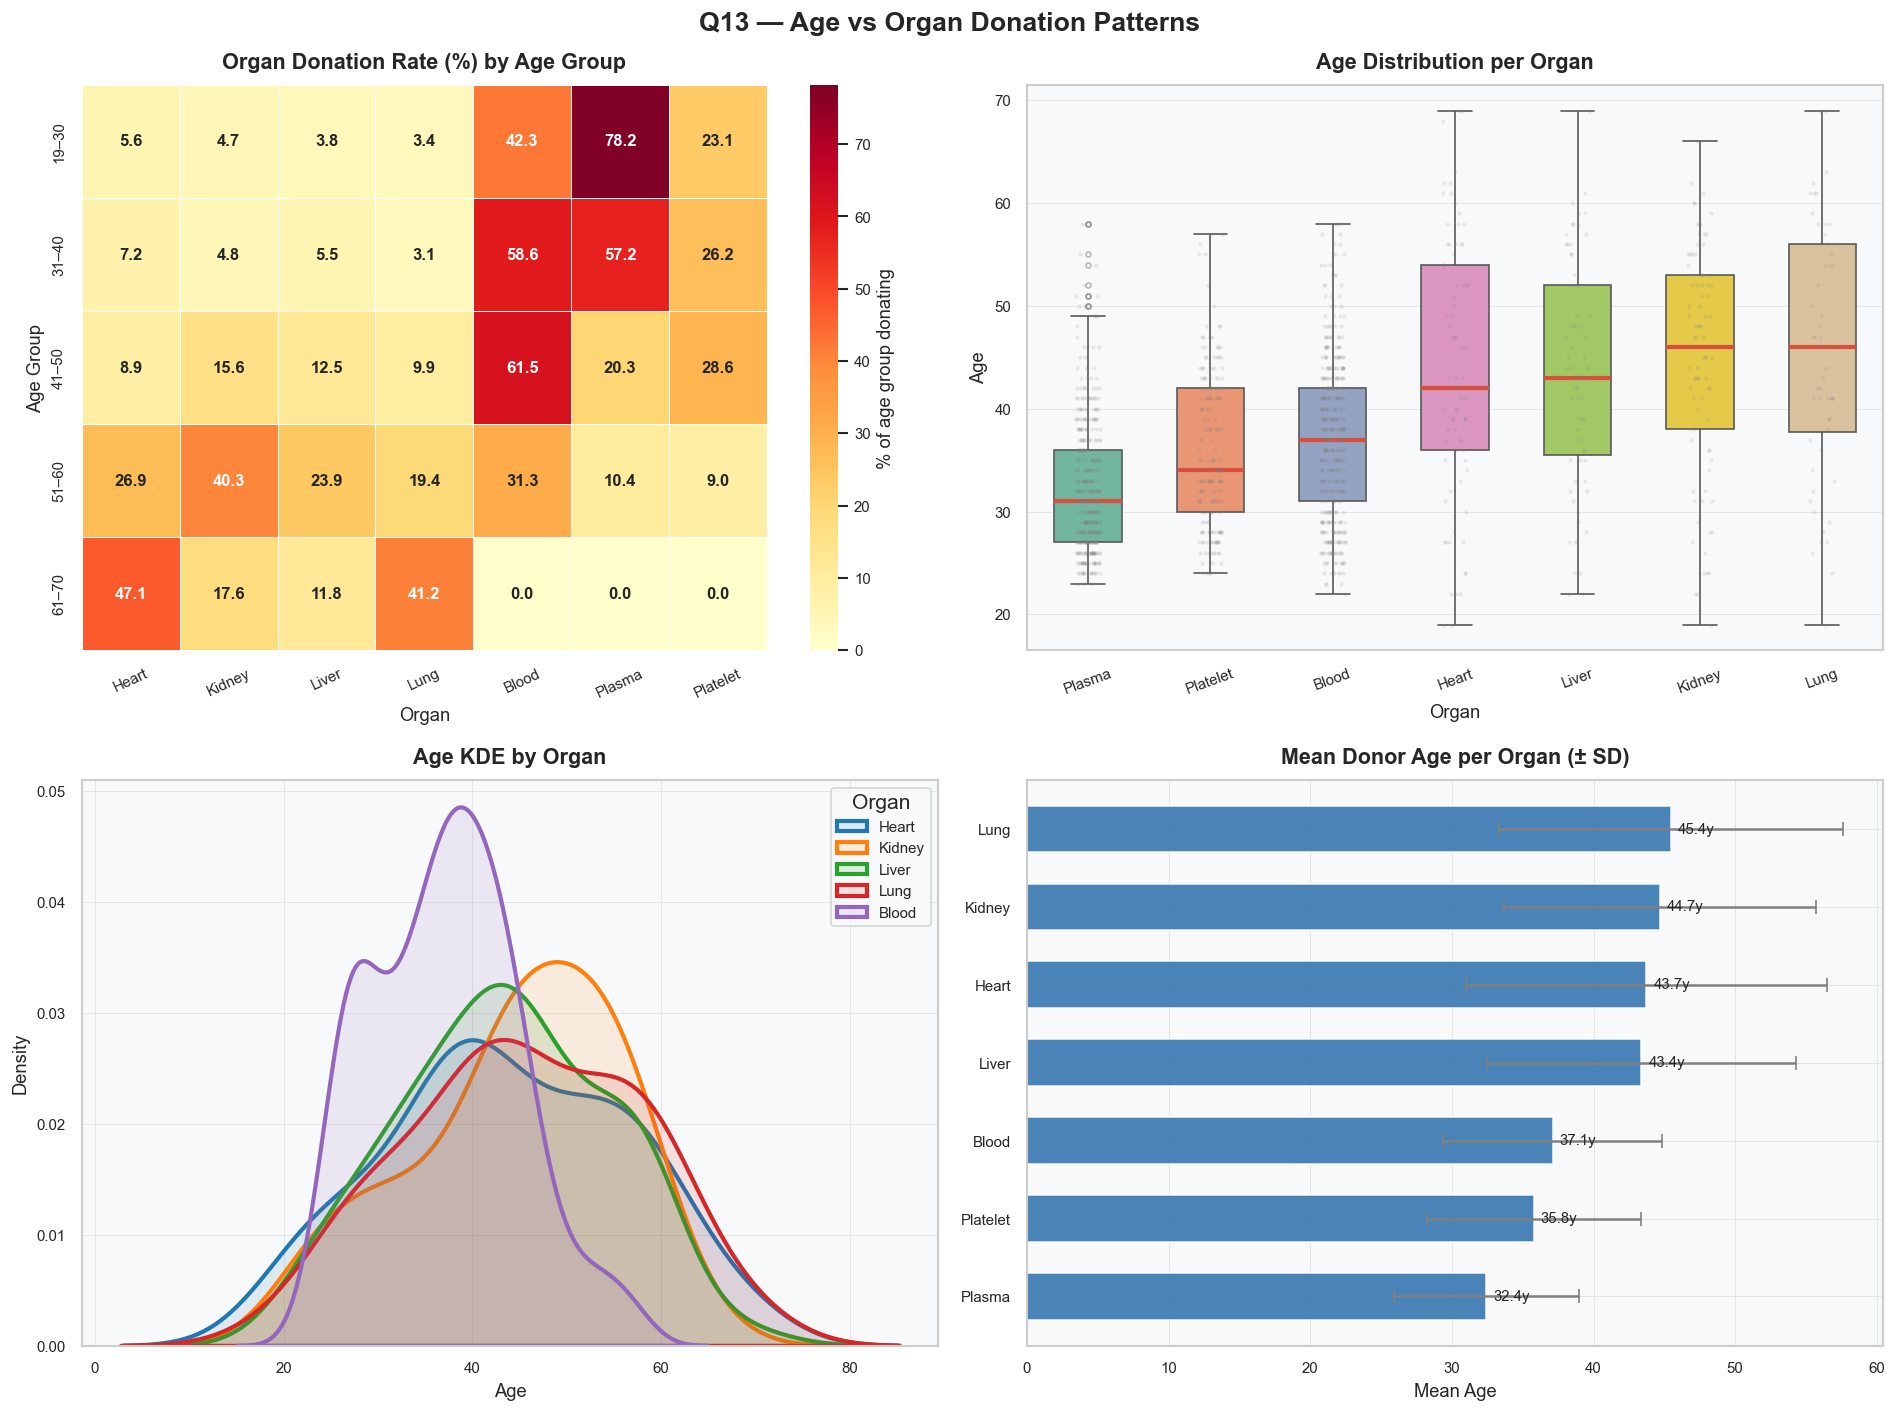


📊 MEAN DONOR AGE BY ORGAN
  Plasma      : Mean=32.4  SD=6.5
  Platelet    : Mean=35.8  SD=7.5
  Blood       : Mean=37.1  SD=7.7
  Liver       : Mean=43.4  SD=10.9
  Heart       : Mean=43.7  SD=12.7
  Kidney      : Mean=44.7  SD=11.0
  Lung        : Mean=45.4  SD=12.1

💡 INSIGHT: Blood/Plasma donation rates are consistent across age groups.
   Solid organs (Heart, Lung) show lower donation rates in older age groups
   due to reduced physiological fitness — validating age-based screening guidelines.


In [19]:
focus_organs = ["Heart","Kidney","Liver","Lung","Blood","Plasma","Platelet"]
focus_organs = [o for o in focus_organs if f"org_{o}" in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Q13 — Age vs Organ Donation Patterns", fontsize=16, fontweight="bold")

# Heatmap: age group × organ
ag_org = df.groupby("age_group", observed=True)[[f"org_{o}" for o in focus_organs]].mean()*100
ag_org.columns = focus_organs
sns.heatmap(ag_org, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5,
            linecolor="white", annot_kws={"size":10,"weight":"bold"},
            cbar_kws={"label":"% of age group donating"}, ax=axes[0,0])
axes[0,0].set_title("Organ Donation Rate (%) by Age Group"); axes[0,0].set_xlabel("Organ")
axes[0,0].set_ylabel("Age Group"); axes[0,0].tick_params(axis="x",rotation=25)

# Age boxplot per organ
rows = [{"Organ":o,"Age":v} for o in focus_organs for v in df.loc[df[f"org_{o}"]==1,"age"]]
odf = pd.DataFrame(rows)
order = odf.groupby("Organ")["Age"].median().sort_values().index.tolist()
sns.boxplot(data=odf, x="Organ", y="Age", order=order, palette="Set2",
            ax=axes[0,1], width=0.55,
            medianprops=dict(color=C_RED,linewidth=2.5),
            flierprops=dict(marker="o",markersize=3,alpha=0.4))
sns.stripplot(data=odf, x="Organ", y="Age", order=order,
              color="gray", alpha=0.15, size=2.5, jitter=True, ax=axes[0,1])
axes[0,1].set_title("Age Distribution per Organ"); axes[0,1].set_xlabel("Organ"); axes[0,1].set_ylabel("Age")
axes[0,1].tick_params(axis="x",rotation=20)

# KDE overlay
for org, col in zip(focus_organs[:5], sns.color_palette("tab10",5)):
    sub = df.loc[df[f"org_{org}"]==1,"age"]
    if len(sub)>5:
        sns.kdeplot(sub, ax=axes[1,0], label=org, color=col, lw=2.5, fill=True, alpha=0.12)
axes[1,0].set_title("Age KDE by Organ"); axes[1,0].set_xlabel("Age"); axes[1,0].set_ylabel("Density")
axes[1,0].legend(title="Organ")

# Mean age per organ
mean_ages = odf.groupby("Organ")["Age"].agg(["mean","std"]).sort_values("mean")
axes[1,1].barh(mean_ages.index, mean_ages["mean"], xerr=mean_ages["std"],
               color=C_BLUE, edgecolor="white", height=0.6, capsize=4, ecolor="gray", alpha=0.85)
for bar, v in zip(axes[1,1].patches, mean_ages["mean"]):
    axes[1,1].text(v+0.5, bar.get_y()+bar.get_height()/2,
                   f"{v:.1f}y", va="center", fontsize=9)
axes[1,1].set_title("Mean Donor Age per Organ (± SD)"); axes[1,1].set_xlabel("Mean Age")

plt.tight_layout(); plt.show()

print("\n📊 MEAN DONOR AGE BY ORGAN")
for org, row in mean_ages.iterrows():
    print(f"  {org:<12}: Mean={row['mean']:.1f}  SD={row['std']:.1f}")
print("\n💡 INSIGHT: Blood/Plasma donation rates are consistent across age groups.")
print("   Solid organs (Heart, Lung) show lower donation rates in older age groups")
print("   due to reduced physiological fitness — validating age-based screening guidelines.")

---
## ❓ Question 14: What Is the Relationship Between Medical Conditions and Cause of Death?
**Description:** A donor's pre-existing conditions often directly link to their cause of death.
Diabetic donors are more likely to die from organ failure; hypertensive donors from cardiovascular events.
Understanding this link helps predict which organs may be compromised before the transplant team even
examines them, saving critical time in the matching process.

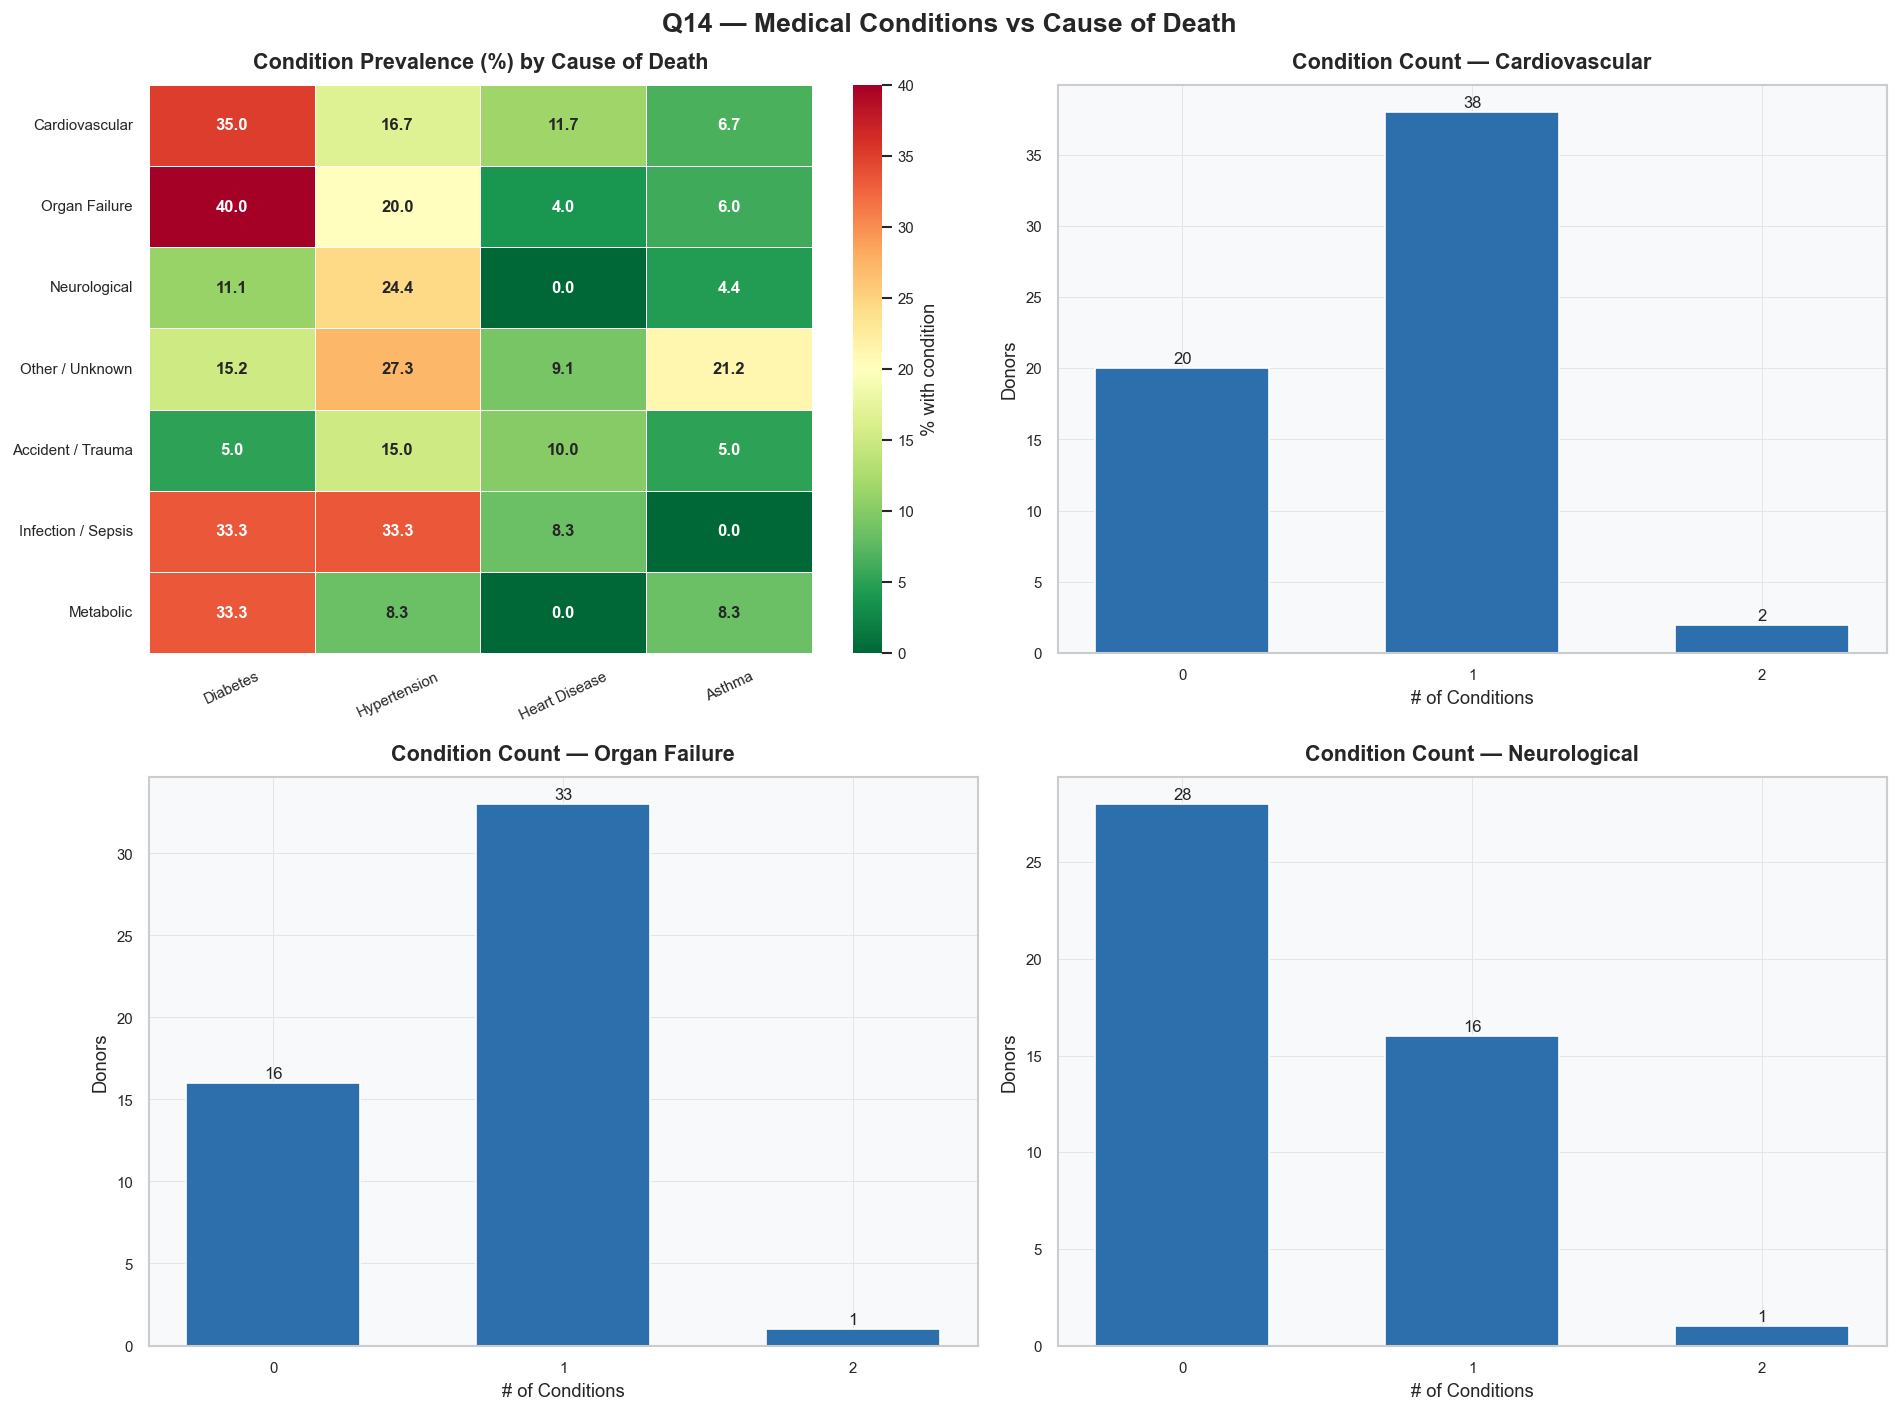


📊 CONDITION–CAUSE ASSOCIATION
  Cardiovascular           :  60 donors  |  Most common condition: Diabetes (35.0%)
  Organ Failure            :  50 donors  |  Most common condition: Diabetes (40.0%)
  Neurological             :  45 donors  |  Most common condition: Hypertension (24.4%)
  Other / Unknown          :  33 donors  |  Most common condition: Hypertension (27.3%)
  Accident / Trauma        :  20 donors  |  Most common condition: Hypertension (15.0%)
  Infection / Sepsis       :  12 donors  |  Most common condition: Diabetes (33.3%)
  Metabolic                :  12 donors  |  Most common condition: Diabetes (33.3%)

💡 INSIGHT: Cardiovascular deaths are strongly linked to Heart Disease and
   Hypertension. Organ Failure deaths co-occur with Diabetes. This provides
   transplant teams with predictive information before detailed organ assessment.


In [20]:
# Build condition × cause matrix for deceased donors
dec_conds = DECEASED.copy()
cond_cols2 = {"Diabetes":"has_diabetes","Hypertension":"has_hypertension",
              "Heart Disease":"has_heart","Asthma":"has_asthma"}

# Filter to meaningful cause categories
top_causes = dec_conds["cause_cat"].value_counts().head(7).index.tolist()
dec_conds_top = dec_conds[dec_conds["cause_cat"].isin(top_causes)]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Q14 — Medical Conditions vs Cause of Death", fontsize=16, fontweight="bold")

# Heatmap: condition prevalence by cause
mat_data = {}
for cause in top_causes:
    sub = dec_conds[dec_conds["cause_cat"]==cause]
    mat_data[cause] = {lbl: sub[col].mean()*100 for lbl, col in cond_cols2.items()}
mat_df = pd.DataFrame(mat_data).T

sns.heatmap(mat_df, annot=True, fmt=".1f", cmap="RdYlGn_r",
            linewidths=0.5, linecolor="white",
            annot_kws={"size":10,"weight":"bold"},
            cbar_kws={"label":"% with condition"}, ax=axes[0,0])
axes[0,0].set_title("Condition Prevalence (%) by Cause of Death")
axes[0,0].tick_params(axis="x",rotation=25,labelsize=9)
axes[0,0].tick_params(axis="y",rotation=0)

# Stacked bar: any condition vs no condition by cause
for ax_idx, (cause_sel, ax_) in enumerate(zip(top_causes[:4], axes.flatten()[1:])):
    sub = dec_conds[dec_conds["cause_cat"]==cause_sel]
    cc_dist = sub["cond_count"].value_counts().sort_index()
    ax_.bar(cc_dist.index.astype(str), cc_dist.values, color=C_BLUE, edgecolor="white", width=0.6)
    for bar, v in zip(ax_.patches, cc_dist.values):
        ax_.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f"{v}", ha="center", va="bottom", fontsize=10)
    ax_.set_title(f"Condition Count — {cause_sel}")
    ax_.set_xlabel("# of Conditions"); ax_.set_ylabel("Donors")

plt.tight_layout(); plt.show()

print("\n📊 CONDITION–CAUSE ASSOCIATION")
for cause in top_causes:
    sub = dec_conds[dec_conds["cause_cat"]==cause]
    cond_pcts = {lbl: sub[col].mean()*100 for lbl,col in cond_cols2.items()}
    top_cond = max(cond_pcts, key=cond_pcts.get)
    print(f"  {cause:<25}: {len(sub):>3} donors  |  Most common condition: {top_cond} ({cond_pcts[top_cond]:.1f}%)")
print("\n💡 INSIGHT: Cardiovascular deaths are strongly linked to Heart Disease and")
print("   Hypertension. Organ Failure deaths co-occur with Diabetes. This provides")
print("   transplant teams with predictive information before detailed organ assessment.")

---
## ❓ Question 15: Comprehensive Donor Dashboard — All Key Metrics at a Glance
**Description:** A single-page executive summary bringing together all the most critical insights:
organ supply, blood type distribution, donor demographics, hepatitis risk, geographic spread,
and cause-of-death breakdown. This dashboard is designed for hospital administrators, transplant
coordinators, and health policy makers to monitor the donor pool at a glance.

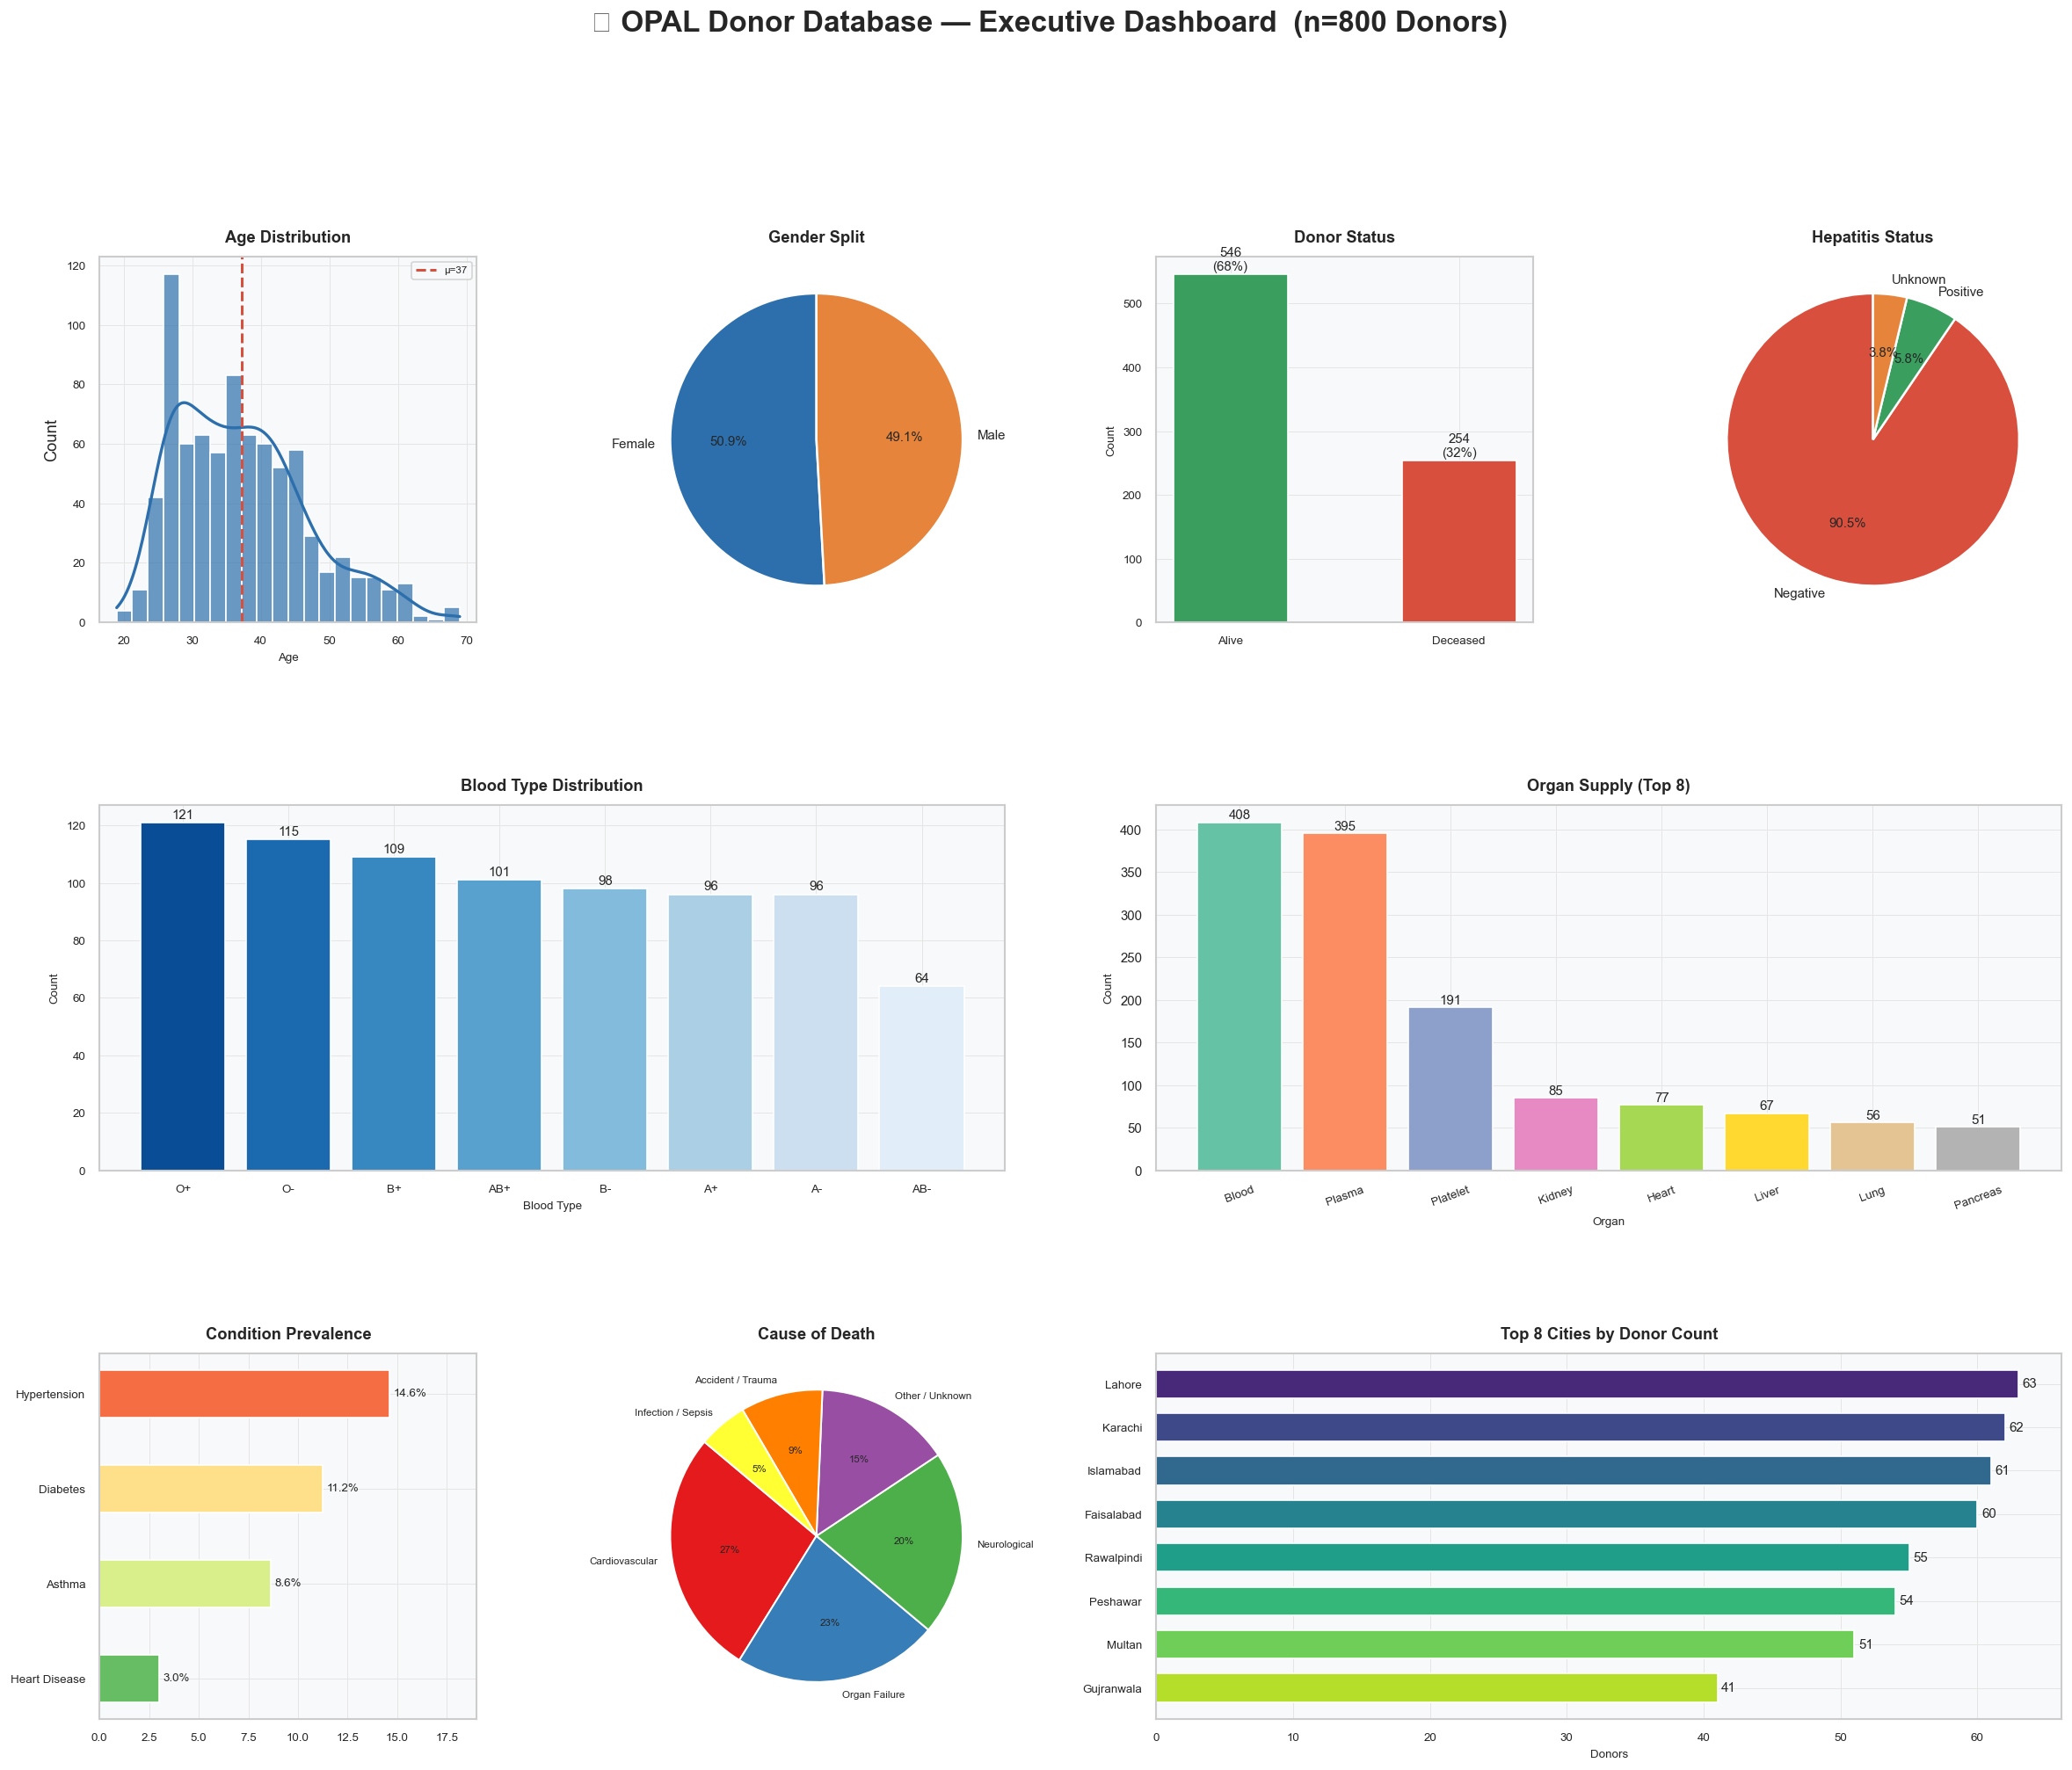


✅ EXECUTIVE SUMMARY
  Total Donors      : 800
  Living / Deceased : 546 / 254
  Age (Mean ± SD)   : 37.3 ± 9.7
  Hepatitis+        : 46 (5.8%)
  Top organ supply  : Blood (408 donors)
  Top city          : Lahore (63 donors)
  Total hospitals   : 203

💡 This dashboard gives decision-makers a complete overview of the donor pool
   in one glance — enabling faster, data-driven organ allocation decisions.


In [21]:
import matplotlib.gridspec as gridspec

organ_counts = pd.Series({o: df[f"org_{o}"].sum() for o in ALL_ORGANS}).sort_values(ascending=False)
blood_counts = df["blood_type"].value_counts()
cause_counts2= DECEASED["cause_cat"].value_counts()
city_top8    = df["city"].value_counts().head(8)
cond_pcts2   = pd.Series({lbl: df[col].mean()*100 for lbl,col in cond_cols2.items()}).sort_values()

fig = plt.figure(figsize=(24, 18))
fig.suptitle("🏥 OPAL Donor Database — Executive Dashboard  (n=800 Donors)",
             fontsize=20, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4)

# A: Age histogram
ax_a = fig.add_subplot(gs[0,0])
sns.histplot(df["age"], bins=22, kde=True, ax=ax_a, color=C_BLUE,
             edgecolor="white", alpha=0.7, line_kws={"lw":2,"color":C_TEAL})
ax_a.axvline(df["age"].mean(), color=C_RED, ls="--", lw=1.8, label=f"μ={df['age'].mean():.0f}")
ax_a.set_title("Age Distribution", fontsize=11, fontweight="bold")
ax_a.set_xlabel("Age",fontsize=8); ax_a.tick_params(labelsize=8); ax_a.legend(fontsize=7)

# B: Gender pie
ax_b = fig.add_subplot(gs[0,1])
gc2 = df["gender"].value_counts()
ax_b.pie(gc2.values, labels=gc2.index, autopct="%1.1f%%",
         colors=[C_BLUE,C_ORANGE], startangle=90,
         wedgeprops=dict(edgecolor="white",linewidth=1.5), textprops={"fontsize":9})
ax_b.set_title("Gender Split", fontsize=11, fontweight="bold")

# C: Alive vs Deceased
ax_c = fig.add_subplot(gs[0,2])
sc2 = df["alive/deceased"].value_counts()
ax_c.bar(sc2.index, sc2.values, color=[C_GREEN,C_RED], edgecolor="white", width=0.5)
for bar, v in zip(ax_c.patches, sc2.values):
    ax_c.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
              f"{v}\n({v/len(df)*100:.0f}%)", ha="center", va="bottom", fontsize=9)
ax_c.set_title("Donor Status", fontsize=11, fontweight="bold")
ax_c.set_ylabel("Count",fontsize=8); ax_c.tick_params(labelsize=8)

# D: Hepatitis
ax_d = fig.add_subplot(gs[0,3])
hep2 = df["hepatitis_status"].value_counts()
ax_d.pie(hep2.values, labels=hep2.index, autopct="%1.1f%%",
         colors=[C_RED,C_GREEN,C_ORANGE][:len(hep2)],
         startangle=90, wedgeprops=dict(edgecolor="white",linewidth=1.5), textprops={"fontsize":9})
ax_d.set_title("Hepatitis Status", fontsize=11, fontweight="bold")

# E: Blood types
ax_e = fig.add_subplot(gs[1,0:2])
ax_e.bar(blood_counts.index, blood_counts.values,
         color=sns.color_palette("Blues_r",len(blood_counts)), edgecolor="white")
for bar, v in zip(ax_e.patches, blood_counts.values):
    ax_e.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
              f"{v}", ha="center", va="bottom", fontsize=9)
ax_e.set_title("Blood Type Distribution", fontsize=11, fontweight="bold")
ax_e.set_xlabel("Blood Type",fontsize=8); ax_e.set_ylabel("Count",fontsize=8)
ax_e.tick_params(labelsize=8)

# F: Organ supply
ax_f = fig.add_subplot(gs[1,2:4])
top8_organs = organ_counts.head(8)
ax_f.bar(top8_organs.index, top8_organs.values,
         color=sns.color_palette("Set2",8), edgecolor="white")
for bar, v in zip(ax_f.patches, top8_organs.values):
    ax_f.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
              f"{v}", ha="center", va="bottom", fontsize=9)
ax_f.set_title("Organ Supply (Top 8)", fontsize=11, fontweight="bold")
ax_f.set_xlabel("Organ",fontsize=8); ax_f.set_ylabel("Count",fontsize=8)
ax_f.tick_params(axis="x",rotation=20,labelsize=8)

# G: Conditions
ax_g = fig.add_subplot(gs[2,0])
ax_g.barh(cond_pcts2.index, cond_pcts2.values,
          color=sns.color_palette("RdYlGn_r",len(cond_pcts2)), edgecolor="white", height=0.5)
for bar, v in zip(ax_g.patches, cond_pcts2.values):
    ax_g.text(v+0.2, bar.get_y()+bar.get_height()/2, f"{v:.1f}%", va="center", fontsize=8)
ax_g.set_title("Condition Prevalence", fontsize=11, fontweight="bold"); ax_g.tick_params(labelsize=8)
ax_g.set_xlim(0, cond_pcts2.max()*1.3)

# H: Cause of death
ax_h = fig.add_subplot(gs[2,1])
ax_h.pie(cause_counts2.values[:6], labels=cause_counts2.index[:6], autopct="%1.0f%%",
         colors=sns.color_palette("Set1",6), startangle=140,
         wedgeprops=dict(edgecolor="white",linewidth=1.2), textprops={"fontsize":7})
ax_h.set_title("Cause of Death", fontsize=11, fontweight="bold")

# I: Top cities
ax_i = fig.add_subplot(gs[2,2:4])
ax_i.barh(city_top8.index[::-1], city_top8.values[::-1],
          color=sns.color_palette("viridis",8)[::-1], edgecolor="white", height=0.65)
for bar, v in zip(ax_i.patches, city_top8.values[::-1]):
    ax_i.text(v+0.3, bar.get_y()+bar.get_height()/2, str(v), va="center", fontsize=9)
ax_i.set_title("Top 8 Cities by Donor Count", fontsize=11, fontweight="bold")
ax_i.set_xlabel("Donors",fontsize=8); ax_i.tick_params(labelsize=8)

plt.tight_layout(); plt.show()

print("\n✅ EXECUTIVE SUMMARY")
print(f"  Total Donors      : {len(df)}")
print(f"  Living / Deceased : {len(ALIVE)} / {len(DECEASED)}")
print(f"  Age (Mean ± SD)   : {df['age'].mean():.1f} ± {df['age'].std():.1f}")
print(f"  Hepatitis+        : {(df['hepatitis_status']=='Positive').sum()} ({(df['hepatitis_status']=='Positive').sum()/len(df)*100:.1f}%)")
print(f"  Top organ supply  : {organ_counts.index[0]} ({organ_counts.iloc[0]} donors)")
print(f"  Top city          : {df['city'].value_counts().index[0]} ({df['city'].value_counts().iloc[0]} donors)")
print(f"  Total hospitals   : {df['hospital_name'].nunique()}")
print("\n💡 This dashboard gives decision-makers a complete overview of the donor pool")
print("   in one glance — enabling faster, data-driven organ allocation decisions.")